# Phase 4: Evaluate Extractions Against Ground Truth

Self-contained notebook — no project imports required.  
CPU-only evaluation of cleaned extraction JSONL against a ground truth CSV or JSONL.

**Inputs:**
- `cleaned_extractions.jsonl` — output of Stage 3 (clean)
- Ground truth CSV (with image identifier column) or JSONL (per-type fields)

**Outputs:**
- `evaluation_results.jsonl` — per-image scores (F1, precision, recall, field breakdown)
- Rich summary table

**Dependencies:** `pandas`, `rich`, `python-Levenshtein` (optional, falls back to exact match)

In [1]:
# ============================================================
# Configuration — edit these paths to match your run
# ============================================================
from pathlib import Path

CLEANED_EXTRACTIONS = Path("../evaluation_data/output/cleaned_extractions.jsonl")
GROUND_TRUTH = Path("../evaluation_data/bank/ground_truth_bank.csv")
OUTPUT_DIR = Path("../evaluation_data/output")

# Evaluation method: "order_aware_f1" (default, position matters) or "f1" (set-based)
EVALUATION_METHOD = "order_aware_f1"

# Optional: epoch seconds when the pipeline started (for wall-clock reporting)
WALL_CLOCK_START = None  # e.g. 1713800000.0

# Auto-detect ground truth format
JSONL_MODE = GROUND_TRUTH.suffix == ".jsonl"

# Sanity check
for label, p in [("Extractions", CLEANED_EXTRACTIONS), ("Ground truth", GROUND_TRUTH)]:
    print(f"{label:15s}: {p.resolve()}  [{'OK' if p.exists() else 'MISSING'}]")
print(
    f"{'GT format':15s}: {'JSONL (per-type fields)' if JSONL_MODE else 'CSV (field_definitions lookup)'}"
)

Extractions    : /Users/tod/Desktop/evaluation_data/output/cleaned_extractions.jsonl  [OK]
Ground truth   : /Users/tod/Desktop/evaluation_data/bank/ground_truth_bank.csv  [OK]
GT format      : CSV (field_definitions lookup)


In [2]:
# ============================================================
# Field definitions (embedded from config/field_definitions.yaml)
# ============================================================
#
# Maps document type -> list of fields to evaluate.
# Validation-only fields (TRANSACTION_AMOUNTS_RECEIVED, ACCOUNT_BALANCE)
# are excluded from scoring.
#
# In JSONL mode, these are only used as fallback — each GT record
# carries exactly its type's fields.

DOC_TYPE_FIELDS: dict[str, list[str]] = {
    "invoice": [
        "DOCUMENT_TYPE",
        "BUSINESS_ABN",
        "SUPPLIER_NAME",
        "BUSINESS_ADDRESS",
        "PAYER_NAME",
        "PAYER_ADDRESS",
        "INVOICE_DATE",
        "LINE_ITEM_DESCRIPTIONS",
        "LINE_ITEM_QUANTITIES",
        "LINE_ITEM_PRICES",
        "LINE_ITEM_TOTAL_PRICES",
        "IS_GST_INCLUDED",
        "GST_AMOUNT",
        "TOTAL_AMOUNT",
    ],
    "receipt": [
        "DOCUMENT_TYPE",
        "BUSINESS_ABN",
        "SUPPLIER_NAME",
        "BUSINESS_ADDRESS",
        "PAYER_NAME",
        "PAYER_ADDRESS",
        "INVOICE_DATE",
        "LINE_ITEM_DESCRIPTIONS",
        "LINE_ITEM_QUANTITIES",
        "LINE_ITEM_PRICES",
        "LINE_ITEM_TOTAL_PRICES",
        "IS_GST_INCLUDED",
        "GST_AMOUNT",
        "TOTAL_AMOUNT",
    ],
    "bank_statement": [
        "DOCUMENT_TYPE",
        "STATEMENT_DATE_RANGE",
        "LINE_ITEM_DESCRIPTIONS",
        "TRANSACTION_DATES",
        "TRANSACTION_AMOUNTS_PAID",
    ],
    "travel": [
        "DOCUMENT_TYPE",
        "PASSENGER_NAME",
        "TRAVEL_MODE",
        "TRAVEL_ROUTE",
        "TRAVEL_DATES",
        "INVOICE_DATE",
        "GST_AMOUNT",
        "TOTAL_AMOUNT",
        "SUPPLIER_NAME",
    ],
    "logbook": [
        "DOCUMENT_TYPE",
        "VEHICLE_MAKE",
        "VEHICLE_MODEL",
        "VEHICLE_REGISTRATION",
        "ENGINE_CAPACITY",
        "LOGBOOK_PERIOD_START",
        "LOGBOOK_PERIOD_END",
        "ODOMETER_START",
        "ODOMETER_END",
        "TOTAL_KILOMETERS",
        "BUSINESS_KILOMETERS",
        "BUSINESS_USE_PERCENTAGE",
        "JOURNEY_DATES",
        "JOURNEY_DISTANCES",
        "JOURNEY_PURPOSES",
    ],
}

# Field type sets (drive type-aware matching in the scorer)
BOOLEAN_FIELDS = {"IS_GST_INCLUDED"}
TRANSACTION_LIST_FIELDS = {
    "TRANSACTION_DATES",
    "TRANSACTION_AMOUNTS_PAID",
    "TRANSACTION_AMOUNTS_RECEIVED",
    "ACCOUNT_BALANCE",
    "TRAVEL_DATES",
    "JOURNEY_DATES",
    "JOURNEY_DISTANCES",
}
VALIDATION_ONLY = {"TRANSACTION_AMOUNTS_RECEIVED", "ACCOUNT_BALANCE"}

# Document type equivalence for DOCUMENT_TYPE scoring
# (invoice == receipt for scoring purposes)
_EVAL_EQUIV = {
    "invoice": "invoice_receipt",
    "receipt": "invoice_receipt",
    "tax invoice": "invoice_receipt",
    "purchase receipt": "invoice_receipt",
    "bank_statement": "bank_statement",
    "statement": "bank_statement",
    "bank statement": "bank_statement",
    "travel": "travel",
    "travel_expense": "travel",
    "travel expense": "travel",
    "logbook": "logbook",
    "vehicle_logbook": "logbook",
    "vehicle logbook": "logbook",
}

print(
    f"Field definitions loaded: {', '.join(f'{k}({len(v)})' for k, v in DOC_TYPE_FIELDS.items())}"
)

Field definitions loaded: invoice(14), receipt(14), bank_statement(5), travel(9), logbook(15)


In [3]:
# ============================================================
# Evaluation engine (self-contained, no project imports)
# ============================================================
# NOTE: Scoring logic is kept in sync with production
# common/evaluation_metrics.py::calculate_field_accuracy_f1.
# If you change scoring logic, update production too.
import json
import re
from typing import Any

import pandas as pd

# ---------- I/O helpers ----------


def read_jsonl(path: Path) -> list[dict[str, Any]]:
    """Read all records from a JSONL file."""
    records: list[dict[str, Any]] = []
    with path.open() as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def write_jsonl(path: Path, records: list[dict[str, Any]]) -> int:
    """Write records to a JSONL file. Returns count."""
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w") as f:
        for record in records:
            f.write(json.dumps(record, default=str) + "\n")
    return len(records)


# ---------- Ground truth loading ----------

_GT_FILENAME_KEYS = ("filename", "image_name", "image_file", "file")


def load_ground_truth(gt_path: str | Path) -> dict[str, dict]:
    """Load ground truth from CSV or JSONL into {image_name: {field: value}} dict."""
    gt_path = Path(gt_path)

    if gt_path.suffix == ".jsonl":
        return _load_ground_truth_jsonl(gt_path)
    return _load_ground_truth_csv(gt_path)


def _load_ground_truth_jsonl(path: Path) -> dict[str, dict]:
    """Load JSONL ground truth. Each record carries only its type's fields."""
    gt_map: dict[str, dict] = {}
    records = read_jsonl(path)
    for record in records:
        # Find filename key
        name = None
        for key in _GT_FILENAME_KEYS:
            if key in record:
                name = record[key]
                break
        if not name:
            continue
        gt_map[str(name)] = record
    print(f"Ground truth (JSONL): {len(gt_map)} images from {path.name}")
    return gt_map


def _load_ground_truth_csv(path: Path) -> dict[str, dict]:
    """Load CSV ground truth."""
    df = pd.read_csv(path, dtype=str)
    print(f"Ground truth (CSV): {len(df)} rows, {len(df.columns)} columns")

    image_col = None
    for col in _GT_FILENAME_KEYS:
        if col in df.columns:
            image_col = col
            break
    if image_col is None:
        raise ValueError(
            f"No image identifier column found. Expected one of: {_GT_FILENAME_KEYS}"
        )

    gt_map = {}
    for _, row in df.iterrows():
        name = row[image_col]
        if pd.isna(name):
            continue
        gt_map[str(name)] = row.to_dict()
    print(f"Ground truth mapping: {len(gt_map)} images")
    return gt_map


# ---------- Date comparison helpers ----------

_MONTHS = {
    "jan": 1,
    "january": 1,
    "feb": 2,
    "february": 2,
    "mar": 3,
    "march": 3,
    "apr": 4,
    "april": 4,
    "may": 5,
    "jun": 6,
    "june": 6,
    "jul": 7,
    "july": 7,
    "aug": 8,
    "august": 8,
    "sep": 9,
    "sept": 9,
    "september": 9,
    "oct": 10,
    "october": 10,
    "nov": 11,
    "november": 11,
    "dec": 12,
    "december": 12,
}

# String-keyed month lookup used by _compare_dates_fuzzy (matches production).
_MONTHS_STR: dict[str, str] = {k: str(v).zfill(2) for k, v in _MONTHS.items()}


def _parse_single_date(date_str: str) -> tuple[int, int, int] | None:
    """Parse a date string to (day, month, year)."""
    s = date_str.strip().lower()
    for dn in [
        "monday",
        "tuesday",
        "wednesday",
        "thursday",
        "friday",
        "saturday",
        "sunday",
        "mon",
        "tue",
        "wed",
        "thu",
        "fri",
        "sat",
        "sun",
    ]:
        if s.startswith(dn):
            s = s[len(dn) :].strip()
            break
    nums = re.findall(r"\d+", s)
    month_num = None
    for mn, mv in _MONTHS.items():
        if mn in s:
            month_num = mv
            break
    if not nums:
        return None
    if len(nums) >= 3:
        day, month, year = int(nums[0]), int(nums[1]), int(nums[2])
    elif len(nums) == 2 and month_num:
        day, month, year = int(nums[0]), month_num, int(nums[1])
    elif len(nums) == 2:
        day, month, year = int(nums[0]), int(nums[1]), 0
    else:
        return None
    if year < 100:
        year = 2000 + year if year <= 50 else 1900 + year
    return (day, month, year)


def _parse_date_range(text: str) -> list[tuple[int, int, int]]:
    """Parse date range -> list of (day, month, year)."""
    dates: list[tuple[int, int, int]] = []
    for sep in [" - ", " to ", " \u2013 ", " \u2014 ", "-"]:
        if sep in text.lower():
            parts = text.split(sep) if sep != "-" else re.split(r"\s*-\s*", text)
            parts = [p.strip() for p in parts if p.strip() and len(p.strip()) > 4]
            if len(parts) >= 2:
                for part in parts[:2]:
                    parsed = _parse_single_date(part)
                    if parsed:
                        dates.append(parsed)
                break
    if not dates:
        parsed = _parse_single_date(text)
        if parsed:
            dates.append(parsed)
    return dates


def _compare_date_field(
    extracted: str, ground_truth: str, field_name: str = "", debug: bool = False
) -> float:
    """Semantic date comparison handling ranges and format variations.

    Matches production common.evaluation_metrics._compare_date_field signature.
    """
    ext_dates = _parse_date_range(extracted)
    gt_dates = _parse_date_range(ground_truth)
    if not ext_dates or not gt_dates:
        return 0.0
    if set(ext_dates) == set(gt_dates):
        return 1.0
    common = set(ext_dates) & set(gt_dates)
    if common:
        return len(common) / max(len(set(ext_dates)), len(set(gt_dates)))
    e_day, e_month, _ = ext_dates[0]
    g_day, g_month, _ = gt_dates[0]
    if e_day == g_day and e_month == g_month:
        return 0.8
    return 0.0


def _compare_dates_fuzzy(extracted_date: str, ground_truth_date: str) -> bool:
    """Fuzzy date comparison for transaction list items.

    Matches production common.evaluation_metrics._compare_dates_fuzzy — uses
    string-normalised (day, month, year) tuples with ``None`` for missing
    components and requires at least 2 matching non-None parts.
    """
    if extracted_date.strip() == ground_truth_date.strip():
        return True

    def normalize_date(date_str: str) -> tuple[str | None, str | None, str | None] | None:
        """Extract (day, month, year) as zero-padded strings."""
        date_lower = date_str.lower()
        nums = re.findall(r"\d+", date_str)
        month_num: str | None = None
        for month_name, month_val in _MONTHS_STR.items():
            if month_name in date_lower:
                month_num = month_val
                break
        if not nums:
            return None
        if len(nums) == 3:
            day, month, year = nums[0], nums[1], nums[2]
        elif len(nums) == 2 and month_num:
            day, month, year = nums[0], month_num, nums[1]
        elif len(nums) == 2:
            day, month, year = nums[0], None, nums[1]
        elif len(nums) == 1 and month_num:
            day, month, year = nums[0], month_num, None
        else:
            return None
        if year and len(year) == 2:
            year_int = int(year)
            year = str(2000 + year_int) if year_int <= 50 else str(1900 + year_int)
        if day:
            day = day.zfill(2)
        if month:
            month = str(month).zfill(2)
        return (day, month, year)

    extracted_parts = normalize_date(extracted_date)
    ground_truth_parts = normalize_date(ground_truth_date)
    if extracted_parts is None or ground_truth_parts is None:
        return False
    for ext, gt in zip(extracted_parts, ground_truth_parts, strict=False):
        if ext is not None and gt is not None and ext != gt:
            return False
    matches = sum(
        1
        for ext, gt in zip(extracted_parts, ground_truth_parts, strict=False)
        if ext == gt and ext is not None
    )
    return matches >= 2


# ---------- Matching helpers ----------


def _parse_boolean(value: str) -> bool | None:
    """Parse boolean value from text string.

    Matches production common.evaluation_metrics._parse_boolean_value.
    """
    if not value or value == "NOT_FOUND":
        return None
    v = str(value).lower().strip()
    if v in ("true", "1", "yes", "y"):
        return True
    if v in ("false", "0", "no", "n"):
        return False
    return None


def _compare_monetary_values(extracted: str, ground_truth: str) -> float:
    """Compare monetary values with 1% tolerance.

    Matches production common.evaluation_metrics._compare_monetary_values.
    """
    try:
        extracted_num = float(re.sub(r"[^\d.-]", "", extracted))
        ground_truth_num = float(re.sub(r"[^\d.-]", "", ground_truth))
        tolerance = abs(ground_truth_num * 0.01) if ground_truth_num != 0 else 0.01
        return 1.0 if abs(extracted_num - ground_truth_num) <= tolerance else 0.0
    except (ValueError, TypeError):
        return 0.0


def _fuzzy_text_match(t1: str, t2: str, threshold: float = 0.75) -> bool:
    w1, w2 = set(t1.lower().split()), set(t2.lower().split())
    if not w1 or not w2:
        return t1.lower().strip() == t2.lower().strip()
    return len(w1 & w2) / len(w1 | w2) >= threshold


def _transaction_item_matches(ext: str, gt: str, field_name: str) -> bool:
    """Type-aware matching for individual transaction list items.

    Matches production common.evaluation_metrics._transaction_item_matches.
    """
    if "AMOUNT" in field_name or "BALANCE" in field_name:
        return _compare_monetary_values(ext, gt) == 1.0
    if "DATE" in field_name:
        return _compare_dates_fuzzy(ext, gt)
    return ext.lower().strip() == gt.lower().strip()


# ---------- Order-aware F1 scorer ----------


def calculate_field_f1(
    extracted_value: str,
    ground_truth_value: str,
    field_name: str,
) -> dict[str, Any]:
    """Position-aware F1 for a single field.

    Returns {f1_score, precision, recall, tp, fp, fn}.

    Logic is kept in sync with production
    ``common.evaluation_metrics.calculate_field_accuracy_f1``.
    """
    extracted = str(extracted_value).strip() if extracted_value else "NOT_FOUND"
    ground_truth = (
        str(ground_truth_value).strip() if ground_truth_value else "NOT_FOUND"
    )

    def _result(f1: float, p: float, r: float, tp: int, fp: int, fn: int) -> dict:
        return {
            "f1_score": f1,
            "precision": p,
            "recall": r,
            "tp": tp,
            "fp": fp,
            "fn": fn,
        }

    # --- NOT_FOUND handling ---
    if ground_truth.upper() == "NOT_FOUND":
        ok = extracted.upper() == "NOT_FOUND"
        return _result(
            1.0 if ok else 0.0, 1.0 if ok else 0.0, 1.0, 0, 0 if ok else 1, 0
        )
    if extracted.upper() == "NOT_FOUND":
        gt_items = [i.strip() for i in ground_truth.split("|") if i.strip()]
        return _result(0.0, 0.0, 0.0, 0, 0, len(gt_items) if gt_items else 1)

    # --- Single-value fields ---
    if "|" not in extracted and "|" not in ground_truth:
        # Transaction list single items
        if field_name in TRANSACTION_LIST_FIELDS:
            m = _transaction_item_matches(extracted, ground_truth, field_name)
            s = 1.0 if m else 0.0
            return _result(s, s, s, int(m), int(not m), int(not m))

        en = " ".join(extracted.split())
        gn = " ".join(ground_truth.split())

        # Boolean — matches production _parse_boolean_value + NOT_FOUND=false logic
        if field_name in BOOLEAN_FIELDS:
            extracted_bool = _parse_boolean(en)
            ground_truth_bool = _parse_boolean(gn)
            # Business logic: GT NOT_FOUND + extracted false → correct
            if ground_truth.upper() == "NOT_FOUND" and extracted_bool is False:
                m = True
            elif extracted_bool is not None and ground_truth_bool is not None:
                m = extracted_bool == ground_truth_bool
            else:
                m = False
            s = 1.0 if m else 0.0
            return _result(s, s, s, int(m), int(not m), int(not m))

        # DOCUMENT_TYPE equivalence
        if field_name == "DOCUMENT_TYPE":
            ec = _EVAL_EQUIV.get(en.lower(), en.lower())
            gc = _EVAL_EQUIV.get(gn.lower(), gn.lower())
            m = ec == gc
            s = 1.0 if m else 0.0
            return _result(s, s, s, int(m), int(not m), int(not m))

        # Date fields
        date_keywords = ["DATE", "DUE_DATE", "INVOICE_DATE", "STATEMENT_DATE"]
        if any(kw in field_name.upper() for kw in date_keywords):
            s = _compare_date_field(en, gn, field_name)
            return _result(
                s, s, s, 1 if s > 0 else 0, 0 if s > 0 else 1, 0 if s > 0 else 1
            )

        # Monetary single fields
        if field_name in ("GST_AMOUNT", "TOTAL_AMOUNT", "INVOICE_TOTAL", "SUBTOTAL"):
            try:
                e_num = float(re.sub(r"[^\d.-]", "", en))
                g_num = float(re.sub(r"[^\d.-]", "", gn))
                tol = abs(g_num * 0.01) if g_num != 0 else 0.01
                m = abs(e_num - g_num) <= tol
            except (ValueError, TypeError):
                m = False
            s = 1.0 if m else 0.0
            return _result(s, s, s, int(m), int(not m), int(not m))

        # ID fields (ABN, invoice numbers) — exact match
        id_keywords = ["ABN", "NUMBER", "ID", "REFERENCE", "BSB"]
        if any(kw in field_name.upper() for kw in id_keywords):
            label_pat = r"^(ABN|BSB|ACN|GST|TAX|ID|NUMBER|NO\.?|#)\s*:?\s*"
            ec = re.sub(r"[\s\-]", "", re.sub(label_pat, "", en, flags=re.IGNORECASE))
            gc = re.sub(r"[\s\-]", "", re.sub(label_pat, "", gn, flags=re.IGNORECASE))
            s = 1.0 if ec.lower() == gc.lower() else 0.0
        else:
            # Text fields — Levenshtein (ANLS-style) with fallback
            try:
                from Levenshtein import distance as lev_dist

                d = lev_dist(en.lower(), gn.lower())
                mx = max(len(en), len(gn))
                sim = 1.0 - (d / mx) if mx else 1.0
                s = sim if sim >= 0.5 else 0.0
            except ImportError:
                s = 1.0 if en.lower() == gn.lower() else 0.0

        return _result(
            s, s, s, 1 if s > 0.5 else 0, 0 if s > 0.5 else 1, 0 if s > 0.5 else 1
        )

    # --- List fields (pipe-separated) — position-aware ---
    ext_items = [i.strip() for i in extracted.split("|") if i.strip()]
    gt_items = [i.strip() for i in ground_truth.split("|") if i.strip()]

    tp = fp = fn = 0
    for i in range(max(len(ext_items), len(gt_items))):
        if i < len(gt_items) and i < len(ext_items):
            if field_name in TRANSACTION_LIST_FIELDS:
                match = _transaction_item_matches(ext_items[i], gt_items[i], field_name)
            else:
                match = _fuzzy_text_match(ext_items[i], gt_items[i], 0.75)
            if match:
                tp += 1
            else:
                # Substitution error: wrong item at this position = 1 FN only.
                # Do NOT also count FP — that double-penalises a single mistake.
                fn += 1
        elif i < len(gt_items):
            fn += 1
        else:
            fp += 1

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )
    return _result(f1, precision, recall, tp, fp, fn)


# ---------- Simple evaluator (missing/incorrect field lists) ----------


def simple_evaluate(extracted: dict, ground_truth: dict) -> tuple[list[str], list[str]]:
    """Return (missing_fields, incorrect_fields) for reporting."""
    missing, incorrect = [], []
    for field in ground_truth:
        if field in VALIDATION_ONLY:
            continue
        gt_val = str(ground_truth.get(field, "")).strip()
        if not gt_val:
            continue
        ext_val = str(extracted.get(field, "")).strip()
        if not ext_val:
            missing.append(field)
        elif ext_val.lower() != gt_val.lower():
            incorrect.append(field)
    return missing, incorrect


# ---------- Transaction order normalisation ----------

_TRANSACTION_SORT_GROUPS: dict[str, dict[str, Any]] = {
    "bank_statement": {
        "sort_key": "TRANSACTION_DATES",
        "fields": [
            "TRANSACTION_DATES",
            "TRANSACTION_AMOUNTS_PAID",
            "TRANSACTION_AMOUNTS_RECEIVED",
            "LINE_ITEM_DESCRIPTIONS",
            "ACCOUNT_BALANCE",
        ],
    },
}


def _normalize_transaction_order(data: dict[str, str], doc_type: str) -> dict[str, str]:
    """Sort parallel transaction-list fields into chronological order."""
    group = _TRANSACTION_SORT_GROUPS.get(doc_type.lower())
    if not group:
        return data
    sort_key_field = str(group["sort_key"])
    sort_fields: list[str] = list(group["fields"])
    sort_val = str(data.get(sort_key_field, "NOT_FOUND")).strip()
    if sort_val.upper() == "NOT_FOUND" or "|" not in sort_val:
        return data
    sort_items = [i.strip() for i in sort_val.split("|") if i.strip()]
    parsed_dates: list[tuple[int, int, int]] = []
    for d in sort_items:
        parsed = _parse_single_date(d)
        parsed_dates.append(parsed if parsed else (9999, 99, 99))
    sort_order = sorted(
        range(len(parsed_dates)),
        key=lambda i: (parsed_dates[i][2], parsed_dates[i][1], parsed_dates[i][0]),
    )
    if sort_order == list(range(len(sort_order))):
        return data
    result = dict(data)
    for field in sort_fields:
        val = str(data.get(field, "NOT_FOUND")).strip()
        if val.upper() == "NOT_FOUND" or "|" not in val:
            continue
        items = [i.strip() for i in val.split("|") if i.strip()]
        if len(items) != len(sort_order):
            continue
        result[field] = " | ".join(items[i] for i in sort_order)
    return result


print("Evaluation engine loaded.")


Evaluation engine loaded.


In [4]:
# ============================================================
# Run evaluation
# ============================================================
import logging

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
log = logging.getLogger("evaluate")

# 1. Read inputs
records = read_jsonl(CLEANED_EXTRACTIONS)
if not records:
    raise FileNotFoundError(f"No records in {CLEANED_EXTRACTIONS}")
log.info("Read %d cleaned extractions", len(records))

gt_map = load_ground_truth(GROUND_TRUTH)

# 2. Evaluate each record
eval_results: list[dict[str, Any]] = []

for record in records:
    image_name = record["image_name"]
    doc_type = record.get("document_type", "invoice")

    # Skip error records
    if record.get("error"):
        eval_results.append(
            {
                "image_name": image_name,
                "document_type": doc_type,
                "error": record["error"],
                "overall_accuracy": 0,
                "median_f1": 0,
            }
        )
        continue

    # Look up ground truth (exact match, then stem match)
    gt = gt_map.get(image_name, {})
    if not gt:
        stem = Path(image_name).stem
        for k in gt_map:
            if Path(k).stem == stem or k == stem:
                gt = gt_map[k]
                break
    if not gt:
        eval_results.append(
            {
                "image_name": image_name,
                "document_type": doc_type,
                "error": f"No ground truth for {image_name}",
                "overall_accuracy": 0,
                "median_f1": 0,
            }
        )
        continue

    extracted_data = record.get("extracted_data", {})

    # Filter ground truth to doc-type-specific fields.
    # JSONL mode: use the GT record's own keys (each record carries only its
    # type's fields) — no DOC_TYPE_FIELDS lookup needed.
    if JSONL_MODE:
        eval_fields = [k for k in gt if k not in _GT_FILENAME_KEYS]
    else:
        eval_fields = DOC_TYPE_FIELDS.get(
            doc_type.lower(), DOC_TYPE_FIELDS.get("invoice", [])
        )
    filtered_gt = {f: gt[f] for f in eval_fields if f in gt}

    # Normalise transaction order (match production extraction_evaluator.py:303-306)
    extracted_data = _normalize_transaction_order(extracted_data, doc_type)
    filtered_gt = _normalize_transaction_order(filtered_gt, doc_type)

    # Simple eval for missing/incorrect lists
    missing_fields, incorrect_fields = simple_evaluate(extracted_data, filtered_gt)

    # F1 scoring per field
    field_scores: dict[str, dict] = {}
    total_f1 = total_p = total_r = 0.0

    for field in filtered_gt:
        ext_val = extracted_data.get(field, "NOT_FOUND")
        gt_val = filtered_gt.get(field, "NOT_FOUND")
        metrics = calculate_field_f1(ext_val, gt_val, field)
        field_scores[field] = metrics
        total_f1 += metrics["f1_score"]
        total_p += metrics["precision"]
        total_r += metrics["recall"]

    n = len(field_scores)
    overall_acc = total_f1 / n if n else 0.0
    overall_p = total_p / n if n else 0.0
    overall_r = total_r / n if n else 0.0

    # Median F1 (more robust than mean)
    f1_vals = sorted(s["f1_score"] for s in field_scores.values())
    if f1_vals:
        mid = len(f1_vals) // 2
        median_f1 = (
            (f1_vals[mid - 1] + f1_vals[mid]) / 2
            if len(f1_vals) % 2 == 0
            else f1_vals[mid]
        )
    else:
        median_f1 = 0.0

    eval_results.append(
        {
            "image_name": image_name,
            "document_type": doc_type,
            "overall_accuracy": overall_acc,
            "median_f1": median_f1,
            "overall_precision": overall_p,
            "overall_recall": overall_r,
            "total_fields": n,
            "correct_fields": sum(
                1 for s in field_scores.values() if s["f1_score"] == 1.0
            ),
            "missing_fields": missing_fields,
            "incorrect_fields": incorrect_fields,
            "fields_extracted": len(
                [k for k, v in extracted_data.items() if v != "NOT_FOUND"]
            ),
            "field_scores": field_scores,
            "overall_metrics": {
                "overall_accuracy": overall_acc,
                "median_f1": median_f1,
                "overall_precision": overall_p,
                "overall_recall": overall_r,
                "meets_threshold": median_f1 >= 0.8,
            },
        }
    )

# 3. Write output
output_path = OUTPUT_DIR / "evaluation_results.jsonl"
count = write_jsonl(output_path, eval_results)
log.info("Wrote %d evaluation results to %s", count, output_path)

# 4. Summary stats
scored = [r for r in eval_results if "median_f1" in r and not r.get("error")]
if scored:
    avg_median = sum(r["median_f1"] for r in scored) / len(scored)
    avg_mean = sum(r["overall_accuracy"] for r in scored) / len(scored)
    log.info(
        "Summary: %d images, avg F1 (median)=%.3f, avg F1 (mean)=%.3f",
        len(scored),
        avg_median,
        avg_mean,
    )
else:
    log.warning("No images scored -- check ground truth alignment")

INFO: Read 15 cleaned extractions
INFO: Wrote 15 evaluation results to ../evaluation_data/output/evaluation_results.jsonl
INFO: Summary: 15 images, avg F1 (median)=0.868, avg F1 (mean)=0.887


Ground truth (CSV): 15 rows, 20 columns
Ground truth mapping: 15 images


In [5]:
# ============================================================
# Execution Summary (Rich table)
# ============================================================
import time

from rich.console import Console
from rich.table import Table

console = Console()
num = len(eval_results)
total_inference = sum(r.get("processing_time", 0.0) for r in records)

wall_s = (time.time() - WALL_CLOCK_START) if WALL_CLOCK_START else None
denom = wall_s if (wall_s and wall_s > 0) else total_inference
throughput = (num / denom * 60.0) if denom > 0 else 0.0

scored = [r for r in eval_results if "median_f1" in r and not r.get("error")]
avg_mean = (
    sum(r.get("overall_accuracy", 0) for r in scored) / len(scored) if scored else 0.0
)
avg_median = sum(r.get("median_f1", 0) for r in scored) / len(scored) if scored else 0.0

table = Table(title="Execution Summary", show_header=True, header_style="bold")
table.add_column("Metric", style="cyan")
table.add_column("Value", style="green")
table.add_row("Images Processed", str(num))
if wall_s is not None:
    table.add_row("Wall Clock Time", f"{wall_s:.1f}s")
table.add_row("Inference Time", f"{total_inference:.1f}s")
table.add_row("Throughput", f"{throughput:.2f} images/min")
if scored:
    table.add_row("Avg F1 (mean)", f"{avg_mean:.3f}")
    table.add_row("Avg F1 (median)", f"{avg_median:.3f}")
table.add_row("Output Directory", str(OUTPUT_DIR))

console.print()
console.print(table)

# Document type breakdown
doc_types: dict[str, int] = {}
for r in eval_results:
    dt = r.get("document_type", "UNKNOWN")
    doc_types[dt] = doc_types.get(dt, 0) + 1
if doc_types:
    console.print("\n[bold]Document Types:[/bold]")
    for dt, c in sorted(doc_types.items()):
        console.print(f"  {dt}: {c}")

               Execution Summary                
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Metric           ┃ Value                     ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Images Processed │ 15                        │
│ Inference Time   │ 1091.1s                   │
│ Throughput       │ 0.82 images/min           │
│ Avg F1 (mean)    │ 0.887                     │
│ Avg F1 (median)  │ 0.868                     │
│ Output Directory │ ../evaluation_data/output │
└──────────────────┴───────────────────────────┘

Document Types:

BANK_STATEMENT: 15

In [6]:
# ============================================================
# Per-image results
# ============================================================
for r in eval_results:
    f1 = r.get("median_f1", "N/A")
    acc = r.get("overall_accuracy", "N/A")
    err = r.get("error", "")
    tag = f"  ERROR: {err}" if err else ""
    f1_str = f"{f1:.3f}" if isinstance(f1, float) else str(f1)
    acc_str = f"{acc:.3f}" if isinstance(acc, float) else str(acc)
    print(f"{r['image_name']:40s}  median_f1={f1_str:8s}  accuracy={acc_str}{tag}")

cba_amount_balance.png                    median_f1=1.000     accuracy=0.880
cba_date_grouped.png                      median_f1=1.000     accuracy=0.989
cba_date_grouped_cont.png                 median_f1=1.000     accuracy=0.993
cba_debit_credit.png                      median_f1=1.000     accuracy=0.978
cba_highligted.png                        median_f1=1.000     accuracy=1.000
cba_home_loan.png                         median_f1=0.857     accuracy=0.731
image_003.png                             median_f1=1.000     accuracy=1.000
image_009.png                             median_f1=0.636     accuracy=0.742
low_contrast.png                          median_f1=1.000     accuracy=0.973
nab_classic_highligted.png                median_f1=1.000     accuracy=0.976
synthetic_chrono.png                      median_f1=1.000     accuracy=0.984
synthetic_multiline.png                   median_f1=1.000     accuracy=0.978
synthetic_reverse_chrono.png              median_f1=0.457     accuracy=0.656

In [7]:
# ============================================================
# Misclassified Images — predicted vs ground truth DOCUMENT_TYPE
# ============================================================
from rich.table import Table as RichTable

misclassified: list[dict[str, str]] = []

for r in eval_results:
    if r.get("error"):
        continue
    fs = r.get("field_scores", {})
    dt_score = fs.get("DOCUMENT_TYPE", {})
    if dt_score and dt_score.get("f1_score", 1.0) < 1.0:
        # Look up predicted and ground truth values
        rec = next((x for x in records if x["image_name"] == r["image_name"]), {})
        extracted_data = rec.get("extracted_data", {})
        predicted = extracted_data.get("DOCUMENT_TYPE", r.get("document_type", "?"))

        gt = gt_map.get(r["image_name"], {})
        if not gt:
            stem = Path(r["image_name"]).stem
            for k in gt_map:
                if Path(k).stem == stem or k == stem:
                    gt = gt_map[k]
                    break
        gt_type = gt.get("DOCUMENT_TYPE", "?")

        misclassified.append(
            {
                "image": r["image_name"],
                "predicted": predicted,
                "ground_truth": gt_type,
            }
        )

if misclassified:
    t = RichTable(
        title=f"Misclassified Images ({len(misclassified)})",
        show_header=True,
        header_style="bold red",
    )
    t.add_column("Image", style="cyan")
    t.add_column("Predicted", style="yellow")
    t.add_column("Ground Truth", style="green")
    for m in misclassified:
        t.add_row(m["image"], m["predicted"], m["ground_truth"])
    console.print()
    console.print(t)
else:
    console.print(
        "\n[bold green]All images correctly classified![/bold green] "
        f"({len([r for r in eval_results if not r.get('error')])} images)"
    )

All images correctly classified! (15 images)

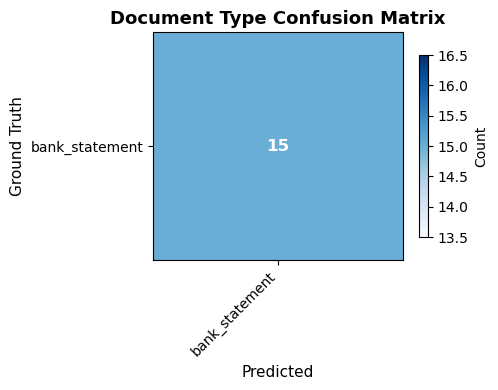


Total scored: 15, Correct: 15, Misclassified: 0 (0.0%)


In [8]:
# ============================================================
# Document Type Confusion Matrix
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# Lighter normalisation — standardise spelling variants but keep
# invoice and receipt as separate categories (unlike _EVAL_EQUIV)
_CM_NORM: dict[str, str] = {
    "invoice": "invoice",
    "tax invoice": "invoice",
    "receipt": "receipt",
    "purchase receipt": "receipt",
    "bank_statement": "bank_statement",
    "statement": "bank_statement",
    "bank statement": "bank_statement",
    "travel": "travel",
    "travel_expense": "travel",
    "travel expense": "travel",
    "logbook": "logbook",
    "vehicle_logbook": "logbook",
    "vehicle logbook": "logbook",
}

# Collect (ground_truth, predicted) pairs for all scored images
pairs: list[dict[str, str]] = []
for r in eval_results:
    if r.get("error"):
        continue
    rec = next((x for x in records if x["image_name"] == r["image_name"]), {})
    pred = rec.get("extracted_data", {}).get(
        "DOCUMENT_TYPE", r.get("document_type", "?")
    )
    gt = gt_map.get(r["image_name"], {})
    if not gt:
        stem = Path(r["image_name"]).stem
        for k in gt_map:
            if Path(k).stem == stem or k == stem:
                gt = gt_map[k]
                break
    gt_type = gt.get("DOCUMENT_TYPE", "?")

    # Normalize spelling only — preserve invoice vs receipt
    pred_norm = _CM_NORM.get(pred.lower(), pred.lower())
    gt_norm = _CM_NORM.get(gt_type.lower(), gt_type.lower())
    pairs.append({"ground_truth": gt_norm, "predicted": pred_norm})

if pairs:
    # Build confusion matrix via pd.crosstab
    df_cm = pd.crosstab(
        pd.Series([p["ground_truth"] for p in pairs], name="Ground Truth"),
        pd.Series([p["predicted"] for p in pairs], name="Predicted"),
    )

    # Render as annotated heatmap
    fig, ax = plt.subplots(
        figsize=(
            max(5, len(df_cm.columns) * 1.2 + 2),
            max(4, len(df_cm.index) * 1.0 + 2),
        )
    )
    data = df_cm.to_numpy()
    im = ax.imshow(data, cmap="Blues", aspect="auto")

    ax.set_xticks(range(len(df_cm.columns)))
    ax.set_xticklabels(df_cm.columns, rotation=45, ha="right", fontsize=10)
    ax.set_yticks(range(len(df_cm.index)))
    ax.set_yticklabels(df_cm.index, fontsize=10)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Ground Truth", fontsize=11)

    # Annotate each cell with counts
    thresh = data.max() / 2.0
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            color = "white" if data[i, j] > thresh else "black"
            ax.text(
                j,
                i,
                str(data[i, j]),
                ha="center",
                va="center",
                fontsize=12,
                fontweight="bold",
                color=color,
            )

    plt.colorbar(im, ax=ax, label="Count", shrink=0.8)
    ax.set_title("Document Type Confusion Matrix", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Print summary
    total = data.sum()
    correct = np.trace(data)
    print(
        f"\nTotal scored: {total}, Correct: {correct}, "
        f"Misclassified: {total - correct} "
        f"({(total - correct) / total * 100:.1f}%)"
    )
else:
    print("No scored images to build confusion matrix.")

In [9]:
# ============================================================
# Field-level breakdown for a single image
# ============================================================
scored = [r for r in eval_results if "field_scores" in r]
if scored:
    sample = scored[0]  # Change index or filter by name
    print(f"Image: {sample['image_name']}  (type: {sample['document_type']})")
    print(
        f"Overall: median_f1={sample['median_f1']:.3f}, accuracy={sample['overall_accuracy']:.3f}"
    )
    print()
    for field, s in sample["field_scores"].items():
        print(
            f"  {field:35s}  F1={s['f1_score']:.3f}  P={s['precision']:.3f}  R={s['recall']:.3f}"
        )
else:
    print("No scored results found.")

Image: cba_amount_balance.png  (type: BANK_STATEMENT)
Overall: median_f1=1.000, accuracy=0.880

  DOCUMENT_TYPE                        F1=1.000  P=1.000  R=1.000
  STATEMENT_DATE_RANGE                 F1=1.000  P=1.000  R=1.000
  LINE_ITEM_DESCRIPTIONS               F1=0.400  P=1.000  R=0.250
  TRANSACTION_DATES                    F1=1.000  P=1.000  R=1.000
  TRANSACTION_AMOUNTS_PAID             F1=1.000  P=1.000  R=1.000


In [10]:
# ============================================================
# Visualization — build DataFrames from eval_results
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# Per-image DataFrame
rows = []
for r in eval_results:
    if r.get("error"):
        continue
    # Find matching record for processing_time
    proc_time = 0.0
    for rec in records:
        if rec["image_name"] == r["image_name"]:
            proc_time = rec.get("processing_time", 0.0)
            break
    rows.append(
        {
            "image": Path(r["image_name"]).stem,
            "doc_type": r.get("document_type", "unknown"),
            "mean_f1": r["overall_accuracy"],
            "median_f1": r["median_f1"],
            "precision": r.get("overall_precision", 0.0),
            "recall": r.get("overall_recall", 0.0),
            "correct": r.get("correct_fields", 0),
            "total": r.get("total_fields", 0),
            "proc_time": proc_time,
        }
    )

df = pd.DataFrame(rows)

# Field-level DataFrame (rows=fields, cols=images)
all_fields: set[str] = set()
for r in eval_results:
    if "field_scores" in r:
        all_fields |= r["field_scores"].keys()

field_rows = []
for field in sorted(all_fields):
    row: dict[str, Any] = {"field": field}
    for r in eval_results:
        if "field_scores" not in r:
            continue
        stem = Path(r["image_name"]).stem
        row[stem] = r["field_scores"].get(field, {}).get("f1_score", np.nan)
    field_rows.append(row)

df_fields = pd.DataFrame(field_rows).set_index("field")

print(f"Dashboard data: {len(df)} images, {len(df_fields)} fields")
display(df[["image", "doc_type", "mean_f1", "median_f1", "precision", "recall"]])

Dashboard data: 15 images, 5 fields


,image,doc_type,mean_f1,median_f1,precision,recall
0,cba_amount_balance,BANK_STATEMENT,0.880000,1.000000,1.0,0.850000
1,cba_date_grouped,BANK_STATEMENT,0.989474,1.000000,1.0,0.980000
2,cba_date_grouped_cont,BANK_STATEMENT,0.993103,1.000000,1.0,0.986667
3,cba_debit_credit,BANK_STATEMENT,0.977778,1.000000,1.0,0.960000
4,cba_highligted,BANK_STATEMENT,1.000000,1.000000,1.0,1.000000
5,cba_home_loan,BANK_STATEMENT,0.731429,0.857143,1.0,0.650000
6,image_003,BANK_STATEMENT,1.000000,1.000000,1.0,1.000000
7,image_009,BANK_STATEMENT,0.741558,0.636364,1.0,0.640000
8,low_contrast,BANK_STATEMENT,0.972859,1.000000,1.0,0.950000
9,nab_classic_highligted,BANK_STATEMENT,0.976104,1.000000,1.0,0.955556


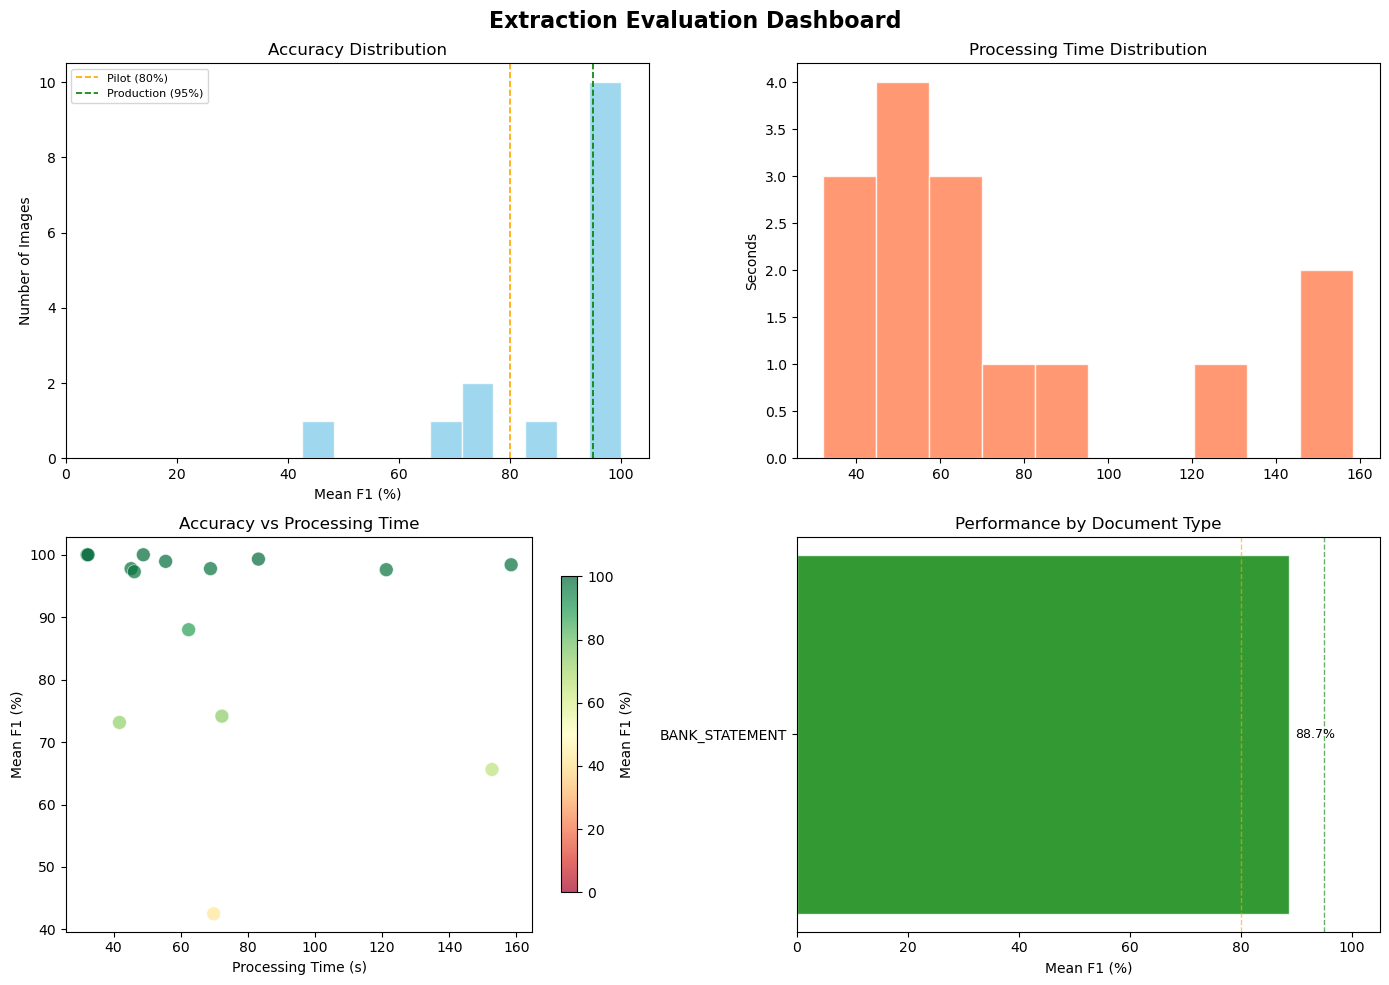

In [11]:
# ============================================================
# 2x2 Performance Dashboard
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Extraction Evaluation Dashboard", fontsize=16, fontweight="bold", y=0.98)

# --- Panel 1: Accuracy distribution histogram ---
ax = axes[0, 0]
accuracies = df["mean_f1"].to_numpy() * 100
if len(set(accuracies)) > 1:
    ax.hist(accuracies, bins=10, color="skyblue", edgecolor="white", alpha=0.8)
else:
    ax.bar(["All images"], [len(accuracies)], color="skyblue", edgecolor="white")
    ax.set_ylabel("Count")
ax.axvline(80, color="orange", linestyle="--", linewidth=1.2, label="Pilot (80%)")
ax.axvline(95, color="green", linestyle="--", linewidth=1.2, label="Production (95%)")
ax.set_xlabel("Mean F1 (%)")
ax.set_ylabel("Number of Images")
ax.set_title("Accuracy Distribution")
ax.set_xlim(0, 105)
ax.legend(fontsize=8)

# --- Panel 2: Processing time distribution ---
ax = axes[0, 1]
times = df["proc_time"].to_numpy()
if times.sum() > 0:
    doc_types_unique = df["doc_type"].unique()
    if len(doc_types_unique) > 1:
        data_by_type = [
            df.loc[df["doc_type"] == dt, "proc_time"].to_numpy()
            for dt in doc_types_unique
        ]
        bp = ax.boxplot(data_by_type, labels=doc_types_unique, patch_artist=True)
        for patch in bp["boxes"]:
            patch.set_facecolor("coral")
            patch.set_alpha(0.7)
    else:
        ax.hist(times, bins=10, color="coral", edgecolor="white", alpha=0.8)
    ax.set_ylabel("Seconds")
    ax.set_title("Processing Time Distribution")
else:
    ax.text(
        0.5,
        0.5,
        "No timing data",
        ha="center",
        va="center",
        transform=ax.transAxes,
        fontsize=12,
        color="grey",
    )
    ax.set_title("Processing Time Distribution")

# --- Panel 3: Accuracy vs Processing Time ---
ax = axes[1, 0]
if times.sum() > 0:
    scatter = ax.scatter(
        times,
        accuracies,
        c=accuracies,
        cmap="RdYlGn",
        vmin=0,
        vmax=100,
        s=100,
        alpha=0.7,
        edgecolors="white",
        linewidth=0.5,
    )
    plt.colorbar(scatter, ax=ax, label="Mean F1 (%)", shrink=0.8)
    ax.set_xlabel("Processing Time (s)")
    ax.set_ylabel("Mean F1 (%)")
else:
    ax.barh(df["image"], accuracies, color="skyblue", edgecolor="white")
    ax.set_xlabel("Mean F1 (%)")
    ax.axvline(80, color="orange", linestyle="--", linewidth=1)
    ax.axvline(95, color="green", linestyle="--", linewidth=1)
ax.set_title("Accuracy vs Processing Time")

# --- Panel 4: Document type performance ---
ax = axes[1, 1]
dtype_perf = df.groupby("doc_type")["mean_f1"].mean() * 100
colors = [
    "red" if v < 60 else "orange" if v < 80 else "green" for v in dtype_perf.to_numpy()
]
bars = ax.barh(
    dtype_perf.index,
    dtype_perf.to_numpy(),
    color=colors,
    edgecolor="white",
    alpha=0.8,
)
for bar, val in zip(bars, dtype_perf.to_numpy(), strict=False):
    ax.text(
        val + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=9,
    )
ax.axvline(80, color="orange", linestyle="--", linewidth=1, alpha=0.6)
ax.axvline(95, color="green", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Mean F1 (%)")
ax.set_xlim(0, 105)
ax.set_title("Performance by Document Type")

plt.tight_layout()
plt.show()

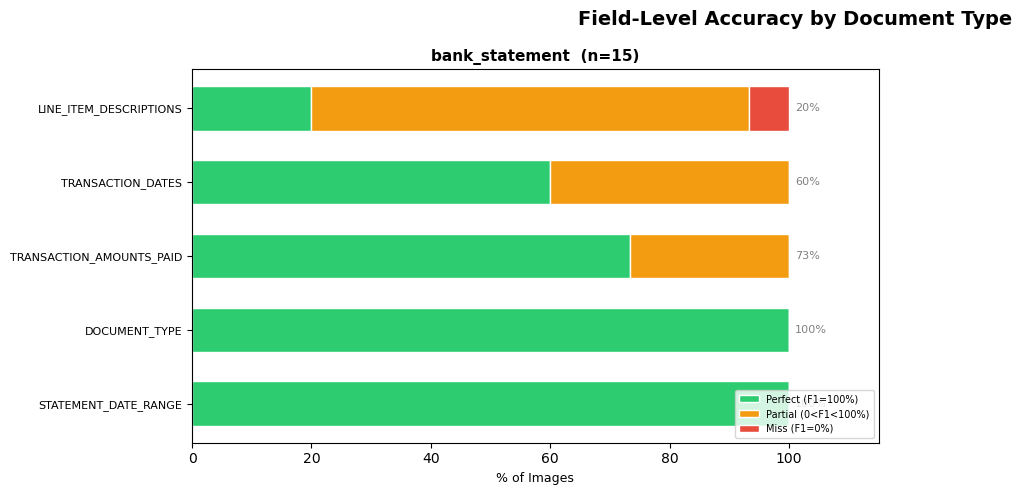


Field Summary Statistics:


,Avg F1 (%),Min F1 (%),Max F1 (%),Std (%)
field,,,,
DOCUMENT_TYPE,100.0,100.0,100.0,0.0
STATEMENT_DATE_RANGE,100.0,100.0,100.0,0.0
TRANSACTION_AMOUNTS_PAID,85.5,6.2,100.0,29.1
TRANSACTION_DATES,82.8,6.2,100.0,29.7
LINE_ITEM_DESCRIPTIONS,75.1,0.0,100.0,31.2


In [12]:
# ============================================================
# Field-Level Accuracy (faceted grid by document type)
# ============================================================

# Build long-form DataFrame: one row per (image, field, doc_type)
field_long_rows: list[dict[str, Any]] = []
for r in eval_results:
    if "field_scores" not in r:
        continue
    doc_type = _CM_NORM.get(r["document_type"].lower(), r["document_type"].lower())
    for field, scores in r["field_scores"].items():
        field_long_rows.append(
            {
                "field": field,
                "f1": scores["f1_score"] * 100,
                "doc_type": doc_type,
            }
        )

df_field_long = pd.DataFrame(field_long_rows)

if not df_field_long.empty:
    doc_types_present = sorted(df_field_long["doc_type"].unique())
    n_panels = len(doc_types_present)
    n_cols = 2
    n_rows = (n_panels + n_cols - 1) // n_cols

    # Find max number of fields across all doc types (for consistent subplot height)
    max_fields = max(
        df_field_long.loc[df_field_long["doc_type"] == dt, "field"].nunique()
        for dt in doc_types_present
    )

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(16, max(5, max_fields * 0.45) * n_rows),
        squeeze=False,
    )

    for idx, dt in enumerate(doc_types_present):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]
        dt_data = df_field_long[df_field_long["doc_type"] == dt]

        # Categorise each (image, field) as perfect / partial / miss
        agg = dt_data.groupby("field")["f1"].agg(
            n_total="count",
            n_perfect=lambda x: (x == 100).sum(),
            n_miss=lambda x: (x == 0).sum(),
        )
        agg["n_partial"] = agg["n_total"] - agg["n_perfect"] - agg["n_miss"]
        agg["pct_perfect"] = agg["n_perfect"] / agg["n_total"] * 100
        agg["pct_partial"] = agg["n_partial"] / agg["n_total"] * 100
        agg["pct_miss"] = agg["n_miss"] / agg["n_total"] * 100

        # Sort by pct_perfect ascending (worst fields at top)
        agg = agg.sort_values("pct_perfect", ascending=True)
        fields_sorted = agg.index.tolist()
        n_images = int(agg["n_total"].iloc[0]) if len(fields_sorted) else 0
        y_pos = range(len(fields_sorted))

        # Stacked horizontal bars
        ax.barh(
            y_pos,
            agg["pct_perfect"],
            height=0.6,
            color="#2ecc71",
            edgecolor="white",
            label="Perfect (F1=100%)",
        )
        ax.barh(
            y_pos,
            agg["pct_partial"],
            height=0.6,
            left=agg["pct_perfect"],
            color="#f39c12",
            edgecolor="white",
            label="Partial (0<F1<100%)",
        )
        ax.barh(
            y_pos,
            agg["pct_miss"],
            height=0.6,
            left=agg["pct_perfect"] + agg["pct_partial"],
            color="#e74c3c",
            edgecolor="white",
            label="Miss (F1=0%)",
        )

        for i, field in enumerate(fields_sorted):
            pct = agg.loc[field, "pct_perfect"]
            ax.text(101, i, f"{pct:.0f}%", va="center", fontsize=8, color="grey")

        ax.set_yticks(y_pos)
        ax.set_yticklabels(fields_sorted, fontsize=8)
        ax.set_xlim(0, 115)
        ax.set_title(f"{dt}  (n={n_images})", fontsize=11, fontweight="bold")
        ax.invert_yaxis()
        ax.set_xlabel("% of Images", fontsize=9)

        if idx == 0:
            ax.legend(loc="lower right", fontsize=7)

    # Hide unused subplot(s)
    for idx in range(n_panels, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row][col].set_visible(False)

    fig.suptitle(
        "Field-Level Accuracy by Document Type", fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

    # Field summary statistics table
    summary = (
        pd.DataFrame(
            {
                "Avg F1 (%)": df_fields.mean(axis=1) * 100,
                "Min F1 (%)": df_fields.min(axis=1) * 100,
                "Max F1 (%)": df_fields.max(axis=1) * 100,
                "Std (%)": df_fields.std(axis=1) * 100,
            }
        )
        .round(1)
        .sort_values("Avg F1 (%)", ascending=False)
    )
    print("\nField Summary Statistics:")
    display(summary)
else:
    print("No field-level data to visualize.")

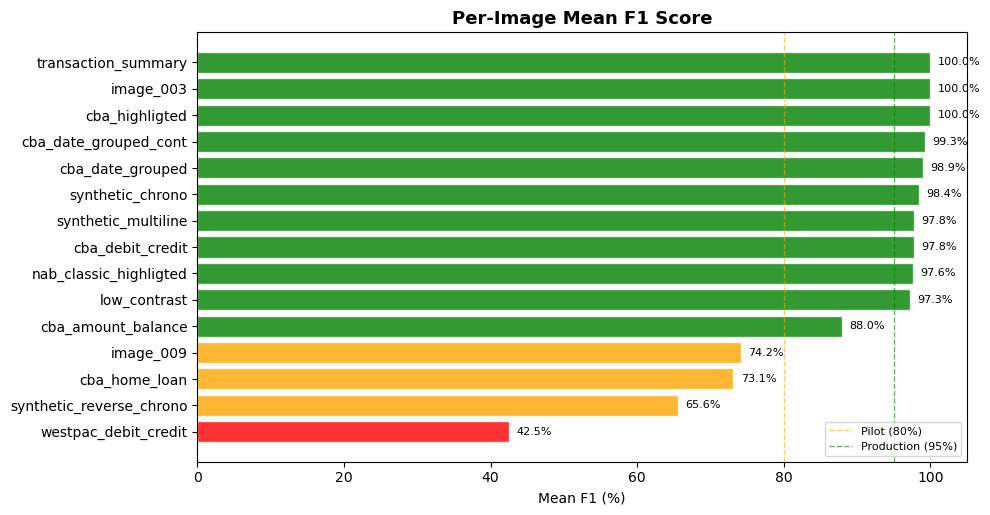

In [13]:
# ============================================================
# Per-Image F1 Scores (ranked bar chart)
# ============================================================
if not df.empty:
    df_sorted = df.sort_values("mean_f1", ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, len(df_sorted) * 0.35)))

    colors = [
        "red" if v < 0.6 else "orange" if v < 0.8 else "green"
        for v in df_sorted["mean_f1"]
    ]
    bars = ax.barh(
        df_sorted["image"],
        df_sorted["mean_f1"] * 100,
        color=colors,
        edgecolor="white",
        alpha=0.8,
    )

    for bar, val in zip(bars, df_sorted["mean_f1"] * 100, strict=False):
        ax.text(
            val + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%",
            va="center",
            fontsize=8,
        )

    ax.axvline(
        80,
        color="orange",
        linestyle="--",
        linewidth=1,
        alpha=0.6,
        label="Pilot (80%)",
    )
    ax.axvline(
        95,
        color="green",
        linestyle="--",
        linewidth=1,
        alpha=0.6,
        label="Production (95%)",
    )
    ax.set_xlabel("Mean F1 (%)")
    ax.set_xlim(0, 105)
    ax.set_title("Per-Image Mean F1 Score", fontsize=13, fontweight="bold")
    ax.legend(fontsize=8, loc="lower right")
    plt.tight_layout()
    plt.show()

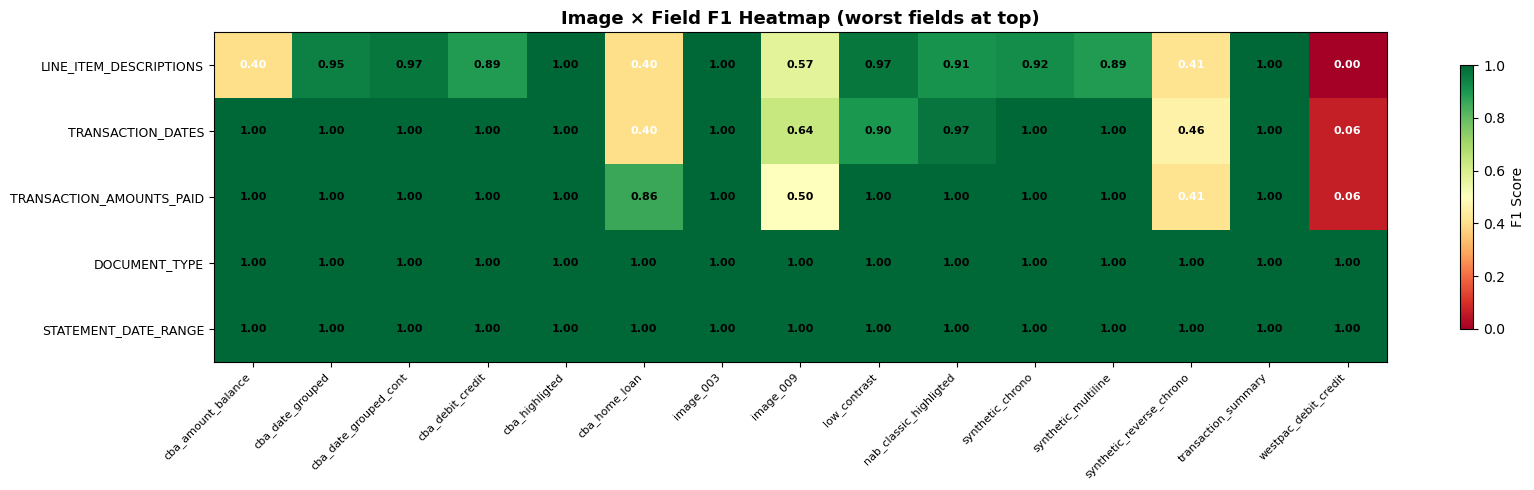

In [14]:
# ============================================================
# Image x Field F1 Heatmap
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# Sort rows by average F1 ascending (worst fields at top)
field_avg = df_fields.mean(axis=1).sort_values(ascending=True)
df_heat = df_fields.loc[field_avg.index]

# Group columns by doc_type: build image_stem -> doc_type mapping
stem_to_dtype: dict[str, str] = {}
for r in eval_results:
    if not r.get("error"):
        stem = Path(r["image_name"]).stem
        stem_to_dtype[stem] = _CM_NORM.get(
            r.get("document_type", "").lower(),
            r.get("document_type", "unknown").lower(),
        )

# Sort columns by (doc_type, stem) so images cluster by type
col_order = sorted(df_heat.columns, key=lambda s: (stem_to_dtype.get(s, "zzz"), s))
df_heat = df_heat[col_order]

data = df_heat.to_numpy(dtype=float)
n_fields, n_images = data.shape

# --- Adaptive sizing for large datasets ---
# Cap width so the figure stays usable; scale cell size down as N grows
cell_w = max(0.55, min(1.1, 14.0 / n_images))
cell_h = max(0.35, min(0.45, 10.0 / n_fields))
fig_w = min(22, max(8, n_images * cell_w + 3))
fig_h = min(14, max(5, n_fields * cell_h + 2))
# Annotation font shrinks with column count; hide text entirely if too dense
annot_fontsize = max(6, min(9, int(130 / n_images)))
show_annotations = n_images <= 40

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
cmap = plt.cm.RdYlGn
cmap.set_bad(color="#f0f0f0")

masked = np.ma.array(data, mask=np.isnan(data))
im = ax.imshow(masked, cmap=cmap, aspect="auto", vmin=0, vmax=1)

# Annotate cells (skip when grid is too dense to read)
if show_annotations:
    for i in range(n_fields):
        for j in range(n_images):
            val = data[i, j]
            if np.isnan(val):
                continue
            color = "white" if val < 0.45 else "black"
            ax.text(
                j, i, f"{val:.2f}",
                ha="center", va="center",
                fontsize=annot_fontsize, fontweight="bold", color=color,
            )

# X-axis labels — compact when many columns
ax.set_xticks(range(n_images))
unique_dtypes = set(stem_to_dtype.values())
if len(unique_dtypes) > 1:
    col_labels = [f"{s}\n({stem_to_dtype.get(s, '?')})" for s in df_heat.columns]
else:
    col_labels = list(df_heat.columns)
label_fontsize = max(6, min(9, int(130 / n_images)))
ax.set_xticklabels(col_labels, rotation=90 if n_images > 15 else 45,
                    ha="center" if n_images > 15 else "right", fontsize=label_fontsize)
ax.set_yticks(range(n_fields))
ax.set_yticklabels(df_heat.index, fontsize=9)

plt.colorbar(im, ax=ax, label="F1 Score", shrink=0.8)
title_extra = "" if show_annotations else "  (hover for values)"
ax.set_title(f"Image × Field F1 Heatmap (worst fields at top){title_extra}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# Error Detail Table — extracted vs ground truth for F1 < 1.0
# ============================================================
from rich.console import Console
from rich.table import Table as RichTable

_err_console = Console()

# Maximum rows to display; set to None to show all
_ERROR_TABLE_LIMIT = 30


def _truncate(text: str, maxlen: int = 80) -> str:
    """Truncate long pipe-separated values."""
    return text if len(text) <= maxlen else text[:maxlen] + "..."


def _is_reversed(ext_items: list[str], gt_items: list[str], field_name: str) -> bool:
    """Check whether the extracted list is the ground truth list reversed."""
    if len(ext_items) < 2 or len(ext_items) != len(gt_items):
        return False
    rev = list(reversed(ext_items))
    for e, g in zip(rev, gt_items, strict=True):
        if field_name in TRANSACTION_LIST_FIELDS:
            if not _transaction_item_matches(e, g, field_name):
                return False
        else:
            if not _fuzzy_text_match(e, g, 0.75):
                return False
    return True


def _classify_error(
    extracted: str, ground_truth: str, field_name: str,
) -> str:
    """Categorise a field error as Missing / Spurious / Wrong / Reversed / Partial."""
    ext = str(extracted).strip() if extracted else "NOT_FOUND"
    gt = str(ground_truth).strip() if ground_truth else "NOT_FOUND"

    if ext.upper() == "NOT_FOUND" and gt.upper() != "NOT_FOUND":
        return "Missing"
    if ext.upper() != "NOT_FOUND" and gt.upper() == "NOT_FOUND":
        return "Spurious"
    # List field checks
    if "|" in ext or "|" in gt:
        ext_items = [i.strip() for i in ext.split("|") if i.strip()]
        gt_items = [i.strip() for i in gt.split("|") if i.strip()]
        if _is_reversed(ext_items, gt_items, field_name):
            return "Reversed"
        return "Partial"
    return "Wrong"


# Build error rows
error_rows: list[dict[str, Any]] = []

for r in eval_results:
    if r.get("error") or "field_scores" not in r:
        continue
    image = r["image_name"]
    doc_type = _CM_NORM.get(
        r.get("document_type", "").lower(),
        r.get("document_type", "unknown").lower(),
    )
    rec = next((x for x in records if x["image_name"] == image), {})
    extracted_data = rec.get("extracted_data", {})

    gt = gt_map.get(image, {})
    if not gt:
        stem = Path(image).stem
        for k in gt_map:
            if Path(k).stem == stem or k == stem:
                gt = gt_map[k]
                break

    # Normalise transaction order to match cell 4 scoring
    _doc = r.get("document_type", "invoice")
    extracted_data = _normalize_transaction_order(extracted_data, _doc)
    gt = _normalize_transaction_order(gt, _doc)

    for field, scores in r["field_scores"].items():
        if scores["f1_score"] >= 1.0:
            continue
        ext_val = str(extracted_data.get(field, "NOT_FOUND")).strip()
        gt_val = str(gt.get(field, "NOT_FOUND")).strip()
        error_rows.append({
            "image": Path(image).stem,
            "doc_type": doc_type,
            "field": field,
            "f1": scores["f1_score"],
            "error_type": _classify_error(ext_val, gt_val, field),
            "extracted": ext_val,
            "ground_truth": gt_val,
        })

# Sort worst first
error_rows.sort(key=lambda x: x["f1"])

if error_rows:
    display_rows = error_rows if _ERROR_TABLE_LIMIT is None else error_rows[:_ERROR_TABLE_LIMIT]
    truncated = len(error_rows) - len(display_rows)
    title = f"Error Details — {len(error_rows)} field(s) with F1 < 1.0"
    if truncated > 0:
        title += f"  (showing worst {len(display_rows)}, {truncated} more omitted)"

    t = RichTable(title=title, show_header=True, header_style="bold")
    t.add_column("Image", style="cyan", no_wrap=True)
    t.add_column("Doc Type", style="dim")
    t.add_column("Field", style="yellow")
    t.add_column("F1", justify="right")
    t.add_column("Error Type", style="bold")
    t.add_column("Extracted", style="red", max_width=80)
    t.add_column("Ground Truth", style="green", max_width=80)

    _etype_colors = {
        "Missing": "red", "Spurious": "magenta", "Wrong": "yellow",
        "Partial": "cyan", "Reversed": "blue",
    }
    for row in display_rows:
        ec = _etype_colors.get(row["error_type"], "white")
        f1_str = f"{row['f1']:.3f}"
        t.add_row(
            row["image"],
            row["doc_type"],
            row["field"],
            f1_str,
            f"[{ec}]{row['error_type']}[/{ec}]",
            _truncate(row["extracted"]),
            _truncate(row["ground_truth"]),
        )
    _err_console.print(t)
    if truncated > 0:
        _err_console.print(
            f"[dim]Set _ERROR_TABLE_LIMIT = None to show all {len(error_rows)} rows.[/dim]"
        )
else:
    _err_console.print("[bold green]All fields have F1 = 1.0 — no errors![/bold green]")

                                     Error Details — 22 field(s) with F1 < 1.0                                     
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Image                    ┃ Doc Type       ┃ Field         ┃    F1 ┃ Error Type ┃ Extracted      ┃ Ground Truth  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ westpac_debit_credit     │ bank_statement │ LINE_ITEM_DE… │ 0.000 │ Partial    │ Stores         │ Stores        │
│                          │                │               │       │            │ Melbourne T2   │ Melbourne T2  │
│                          │                │               │       │            │ Sydney         │ | Sydney      │
│                          │                │               │       │            │ Domestic Aus   │ Domest AUS |  │
│                          │                │               │       │            │ SUBURB NSW     │ SUBURB NSW    │
│                          │                │               │       │            │ TOLL | RETAIL  │ ETOLL |       │
│                          │                │               │       │            │ STORE SUBURB   │ RETAIL STORE  │
│                          │                │               │       │            │ SH...          │ SUBURB...     │
│ westpac_debit_credit     │ bank_statement │ TRANSACTION_… │ 0.062 │ Partial    │ 28/11/2023 |   │ 28 Nov 23 |   │
│                          │                │               │       │            │ 30/11/2023 |   │ 28 Nov 23 |   │
│                          │                │               │       │            │ 01/12/2023 |   │ 28 Nov 23 |   │
│                          │                │               │       │            │ 03/12/2023 |   │ 30 Nov 23 |   │
│                          │                │               │       │            │ 06/12/2023 |   │ 30 Nov 23 |   │
│                          │                │               │       │            │ 07/12/2023 |   │ 01 Dec 23 |   │
│                          │                │               │       │            │ 12...          │ 01 Dec 2...   │
│ westpac_debit_credit     │ bank_statement │ TRANSACTION_… │ 0.062 │ Partial    │ 12.50 | 234.80 │ $12.50 |      │
│                          │                │               │       │            │ | 156.70 |     │ $89.45 |      │
│                          │                │               │       │            │ 78.40 | 345.90 │ $45.90 |      │
│                          │                │               │       │            │ | 750.00 |     │ $234.80 |     │
│                          │                │               │       │            │ 78.40 | 189.50 │ $67.30 |      │
│                          │                │               │       │            │ | 567.80 |     │ $156.70 |     │
│                          │                │               │       │            │ 67...          │ $28.95 |      │
│                          │                │               │       │            │                │ $78.40 |      │
│                          │                │               │       │            │                │ $145.6...     │
│ cba_amount_balance       │ bank_statement │ LINE_ITEM_DE… │ 0.400 │ Partial    │ GROCERY MARKET │ GROCERY       │
│                          │                │               │       │            │ SUBURB NSW AUS │ MARKET SUBURB │
│                          │                │               │       │            │ | DEPARTMENT   │ NSW AUS Card  │
│                          │                │               │       │            │ STORE SHOPPING │ xx5678 |      │
│                          │                │               │       │            │ DIST NS AUS |  │ DEPARTMENT    │
│                          │                │               │       │            │ CAFE CEN...    │ STORE         │
│                          │                │           

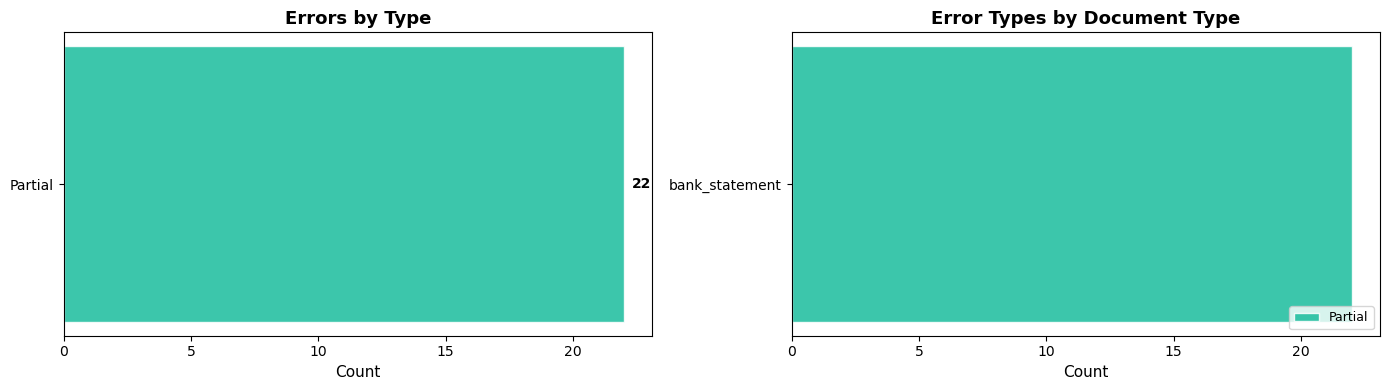

In [16]:
# ============================================================
# Error Type Distribution (two-panel chart)
# ============================================================
import matplotlib.pyplot as plt

if error_rows:
    # Count errors by type
    etype_counts: dict[str, int] = {}
    etype_by_doctype: dict[str, dict[str, int]] = {}

    for row in error_rows:
        et = row["error_type"]
        dt = row["doc_type"]
        etype_counts[et] = etype_counts.get(et, 0) + 1
        if dt not in etype_by_doctype:
            etype_by_doctype[dt] = {}
        etype_by_doctype[dt][et] = etype_by_doctype[dt].get(et, 0) + 1

    error_types_ordered = ["Missing", "Spurious", "Wrong", "Reversed", "Partial"]
    error_colors = {
        "Missing": "#e74c3c",
        "Spurious": "#9b59b6",
        "Wrong": "#f39c12",
        "Reversed": "#3498db",
        "Partial": "#1abc9c",
    }
    # Filter to types that actually appear
    present_types = [et for et in error_types_ordered if etype_counts.get(et, 0) > 0]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(4, len(present_types) * 0.8 + 2)))

    # --- Left panel: overall error type counts ---
    counts = [etype_counts.get(et, 0) for et in present_types]
    bar_colors = [error_colors[et] for et in present_types]
    bars = ax1.barh(present_types, counts, color=bar_colors, edgecolor="white", alpha=0.85)
    for bar, val in zip(bars, counts, strict=False):
        ax1.text(
            val + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=10, fontweight="bold",
        )
    ax1.set_xlabel("Count", fontsize=11)
    ax1.set_title("Errors by Type", fontsize=13, fontweight="bold")
    ax1.invert_yaxis()

    # --- Right panel: stacked bar by doc_type ---
    doc_types_sorted = sorted(etype_by_doctype.keys())
    bottom = np.zeros(len(doc_types_sorted))

    for et in present_types:
        vals = [etype_by_doctype.get(dt, {}).get(et, 0) for dt in doc_types_sorted]
        ax2.barh(
            doc_types_sorted, vals, left=bottom,
            color=error_colors[et], edgecolor="white", alpha=0.85, label=et,
        )
        bottom += np.array(vals)

    ax2.set_xlabel("Count", fontsize=11)
    ax2.set_title("Error Types by Document Type", fontsize=13, fontweight="bold")
    ax2.legend(fontsize=9, loc="lower right")
    ax2.invert_yaxis()

    plt.tight_layout()
    plt.show()
else:
    print("No errors to plot.")

In [17]:
# ============================================================
# List-Field Position-Level Alignment
# ============================================================
from rich.console import Console
from rich.table import Table as RichTable
from rich.text import Text

_align_console = Console()

# Maximum alignment tables to render; set to None to show all
_ALIGNMENT_LIMIT = 15

# Collect all failing list-field entries, sorted by F1, so we show worst first
_align_entries: list[dict[str, Any]] = []

for r in eval_results:
    if r.get("error") or "field_scores" not in r:
        continue
    image = r["image_name"]
    rec = next((x for x in records if x["image_name"] == image), {})
    extracted_data = rec.get("extracted_data", {})

    gt = gt_map.get(image, {})
    if not gt:
        stem = Path(image).stem
        for k in gt_map:
            if Path(k).stem == stem or k == stem:
                gt = gt_map[k]
                break

    # Normalise transaction order to match cell 4 scoring
    _doc = r.get("document_type", "invoice")
    extracted_data = _normalize_transaction_order(extracted_data, _doc)
    gt = _normalize_transaction_order(gt, _doc)

    for field, scores in r["field_scores"].items():
        if scores["f1_score"] >= 1.0:
            continue

        ext_val = str(extracted_data.get(field, "NOT_FOUND")).strip()
        gt_val = str(gt.get(field, "NOT_FOUND")).strip()

        # Only process list fields (pipe-separated in both, or in TRANSACTION_LIST_FIELDS)
        is_list = ("|" in ext_val and "|" in gt_val) or (
            field in TRANSACTION_LIST_FIELDS and ("|" in ext_val or "|" in gt_val)
        )
        if not is_list and field.startswith("LINE_ITEM_") and ("|" in ext_val or "|" in gt_val):
            is_list = True
        if not is_list:
            continue

        _align_entries.append({
            "image": image,
            "field": field,
            "f1": scores["f1_score"],
            "ext_val": ext_val,
            "gt_val": gt_val,
        })

_align_entries.sort(key=lambda x: x["f1"])

if _align_entries:
    display_entries = _align_entries if _ALIGNMENT_LIMIT is None else _align_entries[:_ALIGNMENT_LIMIT]
    omitted = len(_align_entries) - len(display_entries)

    for entry in display_entries:
        ext_val = entry["ext_val"]
        gt_val = entry["gt_val"]
        field = entry["field"]

        ext_items = [i.strip() for i in ext_val.split("|") if i.strip()] if ext_val.upper() != "NOT_FOUND" else []
        gt_items = [i.strip() for i in gt_val.split("|") if i.strip()] if gt_val.upper() != "NOT_FOUND" else []
        max_pos = max(len(ext_items), len(gt_items))
        if max_pos == 0:
            continue

        stem = Path(entry["image"]).stem
        _align_console.print(
            f"\n[bold]Image:[/bold] {stem}  |  "
            f"[bold]Field:[/bold] {field}  |  "
            f"[bold]F1:[/bold] {entry['f1']:.3f}"
        )

        t = RichTable(show_header=True, header_style="bold", padding=(0, 1))
        t.add_column("Pos", justify="right", style="dim", width=4)
        t.add_column("Extracted", style="red", min_width=25, max_width=50)
        t.add_column("Ground Truth", style="green", min_width=25, max_width=50)
        t.add_column("Match", justify="center", width=5)

        for i in range(max_pos):
            ext_item = ext_items[i] if i < len(ext_items) else ""
            gt_item = gt_items[i] if i < len(gt_items) else ""

            if not ext_item and gt_item:
                match_text = Text("MISS", style="bold red")
            elif ext_item and not gt_item:
                match_text = Text("EXTRA", style="bold magenta")
            else:
                if field in TRANSACTION_LIST_FIELDS:
                    matched = _transaction_item_matches(ext_item, gt_item, field)
                else:
                    matched = _fuzzy_text_match(ext_item, gt_item, 0.75)
                match_text = Text("Y", style="bold green") if matched else Text("N", style="bold red")

            t.add_row(
                str(i + 1),
                ext_item if ext_item else "\u2014",
                gt_item if gt_item else "\u2014",
                match_text,
            )

        _align_console.print(t)

    _align_console.print(f"\n[dim]{len(display_entries)} list-field alignment(s) displayed.[/dim]")
    if omitted > 0:
        _align_console.print(
            f"[dim]{omitted} more omitted. Set _ALIGNMENT_LIMIT = None to show all.[/dim]"
        )
else:
    _align_console.print(
        "[bold green]No list-field alignment issues found — "
        "all list fields have F1 = 1.0![/bold green]"
    )

Image: westpac_debit_credit  |  Field: LINE_ITEM_DESCRIPTIONS  |  F1: 0.000

┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃  Pos ┃ Extracted                                          ┃ Ground Truth                           ┃ Match ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│    1 │ Stores Melbourne T2 Sydney Domestic Aus SUBURB NSW │ Stores Melbourne T2                    │   N   │
│      │ TOLL                                               │                                        │       │
│    2 │ RETAIL STORE SUBURB SHOPPING CENTRE SUBURB         │ Sydney Domest AUS                      │   N   │
│    3 │ AUTOMOTIVE SERVICE CAFE PTY LTD                    │ SUBURB NSW ETOLL                       │   N   │
│    4 │ PHARMACY PTY LTD RESTAURANT 2347F FUEL AUSTRALIA   │ RETAIL STORE SUBURB                    │   N   │
│      │ PTY                                                │                                        │       │
│    5 │ C012 Y12-10684-33234 Sydney AUS INSURANCE CO       │ SHOPPING CENTRE SUBURB                 │   N   │
│      │ SYDNEY AUS RETAIL HOTEL PTY LTD LOCATION AUS       │                                        │       │
│    6 │ CASH ADVANCE SPORTING PTY LD DARWIN AUS            │ AUTOMOTIVE SERVICE                     │   N   │
│    7 │ RETAIL BRANDS AU SUBURB AUS PARKING PTY LTD SUBURB │ CAFE PTY LTD                           │   N   │
│      │ DINING BAHAMA SUBURB AUS                           │                                        │       │
│    8 │ RETAIL SERVICES 1849 SUBURB AUS                    │ PHARMACY PTY LTD                       │   N   │
│    9 │ RETAIL COMPANY 1849 SUBURB AUS SHOPPING AUSTRALIA  │ RESTAURANT 2347F                       │   N   │
│      │ SUBURB AUS RETAIL STORES SUBURB AUS                │                                        │       │
│   10 │ SERVICES 123 Accounting SUBURB AUS RETAIL          │ FUEL AUSTRALIA PTY                     │   N   │
│      │ INDUSTRIAL SUBURB EAST AUS                         │                                        │       │
│   11 │ RETAIL STORE 2247F SUBURB AUS CAFE STORE 2247F     │ INSURANCE CO SYDNEY AUS                │   N   │
│      │ SUBURB AUS AUTOMOTIVE SERVICE SUBURB AUS           │                                        │       │
│   12 │ RETAIL STORE FT SUBURB H LOCATION AUS RETAIL       │ RETAIL HOTEL PTY LTD LOCATION AUS      │   N   │
│      │ STORES 1849 SUBURB AUS                             │                                        │       │
│   13 │ RETAIL STORE EARPARK ONL28 SUBURB 28 AUS CRED      │ RETAIL AUSTRALIA PTY                   │   N   │
│      │ VOUCHER                                            │                                        │       │
│   14 │ INTEREST CHARGES - CASH                            │ CASH ADVANCE                           │   N   │
│   15 │ —                                                  │ SPORTING PTY LTD                       │ MISS  │
│   16 │ —                                                  │ RETAIL BRANDS AU SUBURB AUS            │ MISS  │
│   17 │ —                                                  │ PARKING PTY LTD SUBURB AUS             │ MISS  │
│   18 │ —                                                  │ DINING BAHAMA SUBURB AUS               │ MISS  │
│   19 │ —                                                  │ RETAIL SERVICES 1849 SUBURB AUS        │ MISS  │
│   20 │ —                                                  │ RETAIL COMPANY 1849 SUBURB AUS         │ MISS  │
│   21 │ —                                                  │ SHOPPING AUSTRALIA SUBURB AUS          │ MISS  │
│   22 │ —                                                  │ RETAIL STORES SUBURB AUS               │ MISS  │
│   23 │ —                                                  │ SERVICES*123 Accounting SUBURB AUS     │ MISS  │
│   24 │ —                                                  │ RETAIL INDUSTRIAL SUBURB EAST AUS      │ MISS  │
│   

Image: westpac_debit_credit  |  Field: TRANSACTION_DATES  |  F1: 0.062

┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃  Pos ┃ Extracted                 ┃ Ground Truth              ┃ Match ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│    1 │ 28/11/2023                │ 28 Nov 23                 │   Y   │
│    2 │ 30/11/2023                │ 28 Nov 23                 │   N   │
│    3 │ 01/12/2023                │ 28 Nov 23                 │   N   │
│    4 │ 03/12/2023                │ 30 Nov 23                 │   N   │
│    5 │ 06/12/2023                │ 30 Nov 23                 │   N   │
│    6 │ 07/12/2023                │ 01 Dec 23                 │   N   │
│    7 │ 12/12/2023                │ 01 Dec 23                 │   N   │
│    8 │ 13/12/2023                │ 03 Dec 23                 │   N   │
│    9 │ 18/12/2023                │ 03 Dec 23                 │   N   │
│   10 │ 20/12/2023                │ 03 Dec 23                 │   N   │
│   11 │ 22/12/2023                │ 06 Dec 23                 │   N   │
│   12 │ 22/12/2023                │ 06 Dec 23                 │   N   │
│   13 │ 23/12/2023                │ 07 Dec 23                 │   N   │
│   14 │ 26/12/2023                │ 07 Dec 23                 │   N   │
│   15 │ —                         │ 07 Dec 23                 │ MISS  │
│   16 │ —                         │ 12 Dec 23                 │ MISS  │
│   17 │ —                         │ 12 Dec 23                 │ MISS  │
│   18 │ —                         │ 12 Dec 23                 │ MISS  │
│   19 │ —                         │ 13 Dec 23                 │ MISS  │
│   20 │ —                         │ 18 Dec 23                 │ MISS  │
│   21 │ —                         │ 18 Dec 23                 │ MISS  │
│   22 │ —                         │ 18 Dec 23                 │ MISS  │
│   23 │ —                         │ 20 Dec 23                 │ MISS  │
│   24 │ —                         │ 20 Dec 23                 │ MISS  │
│   25 │ —                         │ 22 Dec 23                 │ MISS  │
│   26 │ —                         │ 22 Dec 23                 │ MISS  │
│   27 │ —                         │ 22 Dec 23                 │ MISS  │
│   28 │ —                         │ 22 Dec 23                 │ MISS  │
│   29 │ —                         │ 22 Dec 23                 │ MISS  │
│   30 │ —                         │ 23 Dec 23                 │ MISS  │
│   31 │ —                         │ 26 Dec 23                 │ MISS  │
└──────┴───────────────────────────┴───────────────────────────┴───────┘

Image: westpac_debit_credit  |  Field: TRANSACTION_AMOUNTS_PAID  |  F1: 0.062

...

┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃  Pos ┃ Extracted                                          ┃ Ground Truth                           ┃ Match ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│    1 │ Direct Debit 987654 Loan Repayment 234567          │ Direct Debit 987654 Loan Repayment     │   Y   │
│    2 │ RETAIL STORE SUBURB AU                             │ RETAIL STORE SUBURB AU                 │   Y   │
│    3 │ SUPERMARKET SHOPPING SUBURB AU                     │ SUPERMARKET SHOPPING SUBURB AU         │   Y   │
│    4 │ SHOPPING SUBURB SUBURB AU                          │ SHOPPING SUBURB SUBURB AU              │   Y   │
│    5 │ SHOPPING SUBURB SUBURB AU                          │ SHOPPING SUBURB SUBURB AU              │   Y   │
│    6 │ Store RSL Suburb0 AU Cash Out $89.00               │ Store RSL Suburb0 AU                   │   N   │
│    7 │ Transfer To financially sorted CommBank App Tax    │ Transfer To financially sorted         │   N   │
│    8 │ GROCERY STORE SUBURB AU                            │ GROCERY STORE SUBURB AU                │   Y   │
│    9 │ PETROL STATION SUBURB VICAU                        │ PETROL STATION SUBURB VICAU            │   Y   │
│   10 │ RETAIL STORES SUBURB VICAU                         │ RETAIL STORES SUBURB VICAU             │   Y   │
│   11 │ DEPARTMENT STORE PTY LTD SUBURB VIC AU             │ DEPARTMENT STORE PTY LTD SUBURB VIC AU │   Y   │
│   12 │ RETAIL STORES EASTLINK VIC SUBURB AU               │ RETAIL STORES EASTLINK VIC SUBURB AU   │   Y   │
│   13 │ RETAIL STORE PTY LTD Suburb VICAU                  │ RETAIL STORE PTY LTD Suburb VICAU      │   Y   │
│   14 │ RETAIL STORE PTY LTD Suburb VICAU                  │ RETAIL STORE PTY LTD Suburb VICAU      │   Y   │
│   15 │ Afterpay afterpay.com AU AUS Card xx9012 Value     │ Afterpay afterpay.com AU AUS           │   N   │
│      │ Date: 22/05/2023                                   │                                        │       │
└──────┴────────────────────────────────────────────────────┴────────────────────────────────────────┴───────┘

Image: synthetic_multiline  |  Field: LINE_ITEM_DESCRIPTIONS  |  F1: 0.889

┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃  Pos ┃ Extracted                                   ┃ Ground Truth                                       ┃ Match ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│    1 │ Card Purchase K MART Perth WA               │ Card Purchase KMART PERTH WA                       │   N   │
│    2 │ ATM Withdrawal WESTPAC ATM Perth WA         │ ATM Withdrawal WESTPAC ATM PERTH WA                │   Y   │
│    3 │ Contactless Payment BUNNINGS Canberra ACT   │ Contactless Payment BUNNINGS CANBERRA ACT          │   Y   │
│    4 │ EFTPOS Purchase WOOLWORTHS Sydney NSW       │ EFTPOS Purchase WOOLWORTHS SYDNEY NSW              │   Y   │
│    5 │ Direct Debit ACME CORP PTY LTD              │ Direct Debit ACME CORP PTY LTD Ref: 35203P19335534 │   Y   │
│    6 │ EFTPOS Purchase WOOLWORTHS Hobart TAS       │ EFTPOS Purchase WOOLWORTHS HOBART TAS              │   Y   │
│    7 │ EFTPOS Purchase COLES SUPERMARKET Perth WA  │ EFTPOS Purchase COLES SUPERMARKET PERTH WA         │   Y   │
│    8 │ Insurance Premium AGL Policy 95909FP7706585 │ Insurance Premium AGL Policy 95909P77005685        │   N   │
│    9 │ ATM Withdrawal WESTPAC ATM Brisbane QLD     │ ATM Withdrawal WESTPAC ATM BRISBANE QLD            │   Y   │
│   10 │ Subscription Spotify Monthly 82512P11540956 │ Subscription Spotify Monthly 82512P11540956        │   Y   │
└──────┴─────────────────────────────────────────────┴────────────────────────────────────────────────────┴───────┘

15 list-field alignment(s) displayed.

7 more omitted. Set _ALIGNMENT_LIMIT = None to show all.

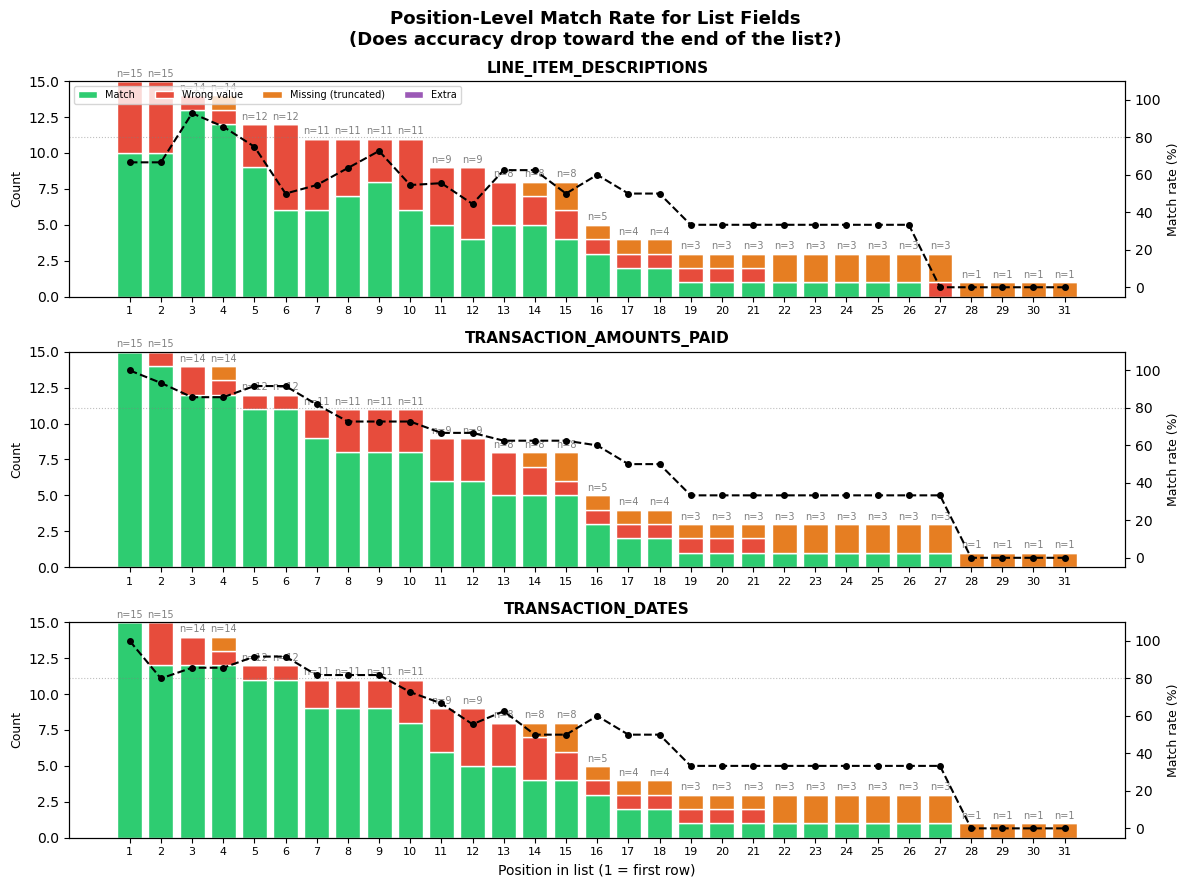


Position vs match-rate summary per field:
  LINE_ITEM_DESCRIPTIONS               r=-0.90  (tail-drop)
  TRANSACTION_AMOUNTS_PAID             r=-0.97  (tail-drop)
  TRANSACTION_DATES                    r=-0.96  (tail-drop)


In [18]:
# ============================================================
# Position-Level Match Rate for List Fields
# ============================================================
# Tests the hypothesis: "Does extraction accuracy degrade toward
# the end of transaction lists?"
#
# Method:
#   For every (image, list-field) pair we walk each position in
#   the pipe-separated list and classify the outcome as one of:
#     - Match:   extracted value at position i matches ground truth
#     - Wrong:   extracted value exists but doesn't match GT
#     - Missing: GT has a value at this position, extraction doesn't
#                (indicates truncation)
#     - Extra:   extraction has a value, GT doesn't (over-extraction)
#
#   Results are pooled across all images, so position 1 aggregates
#   the first item from every image, position 2 from every image,
#   etc. This reveals systematic tail-drop patterns.
#
# Correlation:
#   Pearson r between position index and match-rate at that
#   position (unweighted — each position contributes equally
#   regardless of sample size). Values near -1.0 confirm a
#   linear tail-drop; near 0 means no positional degradation.
#
# Exclusions:
#   Fully-reversed lists are excluded from position counts
#   (they have their own "Reversed" error category) to avoid
#   masking the genuine tail-drop signal.
# ============================================================
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

# Which list fields to include (all pipe-separated fields that appear
# in bank statements, invoices, logbooks, etc.)
_LIST_FIELD_NAMES = TRANSACTION_LIST_FIELDS | {
    f for f in DOC_TYPE_FIELDS.get("bank_statement", [])
    if f.startswith("LINE_ITEM_")
} | {
    f for f in DOC_TYPE_FIELDS.get("invoice", [])
    if f.startswith("LINE_ITEM_")
}

# Collect per-position outcomes: {field: {pos: {outcome: count}}}
_pos_data: dict[str, dict[int, dict[str, int]]] = defaultdict(
    lambda: defaultdict(lambda: {"match": 0, "mismatch": 0, "miss": 0, "extra": 0})
)
_reversed_count: dict[str, int] = defaultdict(int)

for r in eval_results:
    if r.get("error") or "field_scores" not in r:
        continue
    image = r["image_name"]
    rec = next((x for x in records if x["image_name"] == image), {})
    extracted_data = rec.get("extracted_data", {})

    gt = gt_map.get(image, {})
    if not gt:
        stem = Path(image).stem
        for k in gt_map:
            if Path(k).stem == stem or k == stem:
                gt = gt_map[k]
                break

    # Normalise transaction order to match cell 4 scoring
    _doc = r.get("document_type", "invoice")
    extracted_data = _normalize_transaction_order(extracted_data, _doc)
    gt = _normalize_transaction_order(gt, _doc)

    for field in r["field_scores"]:
        if field not in _LIST_FIELD_NAMES:
            continue
        ext_val = str(extracted_data.get(field, "NOT_FOUND")).strip()
        gt_val = str(gt.get(field, "NOT_FOUND")).strip()

        # Skip non-list instances
        if "|" not in ext_val and "|" not in gt_val:
            continue

        ext_items = [i.strip() for i in ext_val.split("|") if i.strip()] if ext_val.upper() != "NOT_FOUND" else []
        gt_items = [i.strip() for i in gt_val.split("|") if i.strip()] if gt_val.upper() != "NOT_FOUND" else []

        # Skip fully-reversed lists — they have their own error category
        if _is_reversed(ext_items, gt_items, field):
            _reversed_count[field] += 1
            continue

        max_pos = max(len(ext_items), len(gt_items))
        for i in range(max_pos):
            ext_item = ext_items[i] if i < len(ext_items) else ""
            gt_item = gt_items[i] if i < len(gt_items) else ""
            pos = i + 1  # 1-indexed

            if not ext_item and gt_item:
                _pos_data[field][pos]["miss"] += 1
            elif ext_item and not gt_item:
                _pos_data[field][pos]["extra"] += 1
            else:
                if field in TRANSACTION_LIST_FIELDS:
                    matched = _transaction_item_matches(ext_item, gt_item, field)
                else:
                    matched = _fuzzy_text_match(ext_item, gt_item, 0.75)
                if matched:
                    _pos_data[field][pos]["match"] += 1
                else:
                    _pos_data[field][pos]["mismatch"] += 1

# --- Plot ---
fields_with_data = sorted(f for f in _pos_data if _pos_data[f])

if fields_with_data:
    n_panels = len(fields_with_data)
    fig, axes = plt.subplots(n_panels, 1, figsize=(12, max(3.5, 3.0 * n_panels)),
                             squeeze=False, sharex=False)

    for idx, field in enumerate(fields_with_data):
        ax = axes[idx][0]
        positions = sorted(_pos_data[field].keys())
        matches = np.array([_pos_data[field][p]["match"] for p in positions])
        mismatches = np.array([_pos_data[field][p]["mismatch"] for p in positions])
        misses = np.array([_pos_data[field][p]["miss"] for p in positions])
        extras = np.array([_pos_data[field][p]["extra"] for p in positions])
        totals = matches + mismatches + misses + extras

        # Stacked bars
        x = np.arange(len(positions))
        ax.bar(x, matches, color="#2ecc71", edgecolor="white", label="Match")
        ax.bar(x, mismatches, bottom=matches, color="#e74c3c", edgecolor="white", label="Wrong value")
        ax.bar(x, misses, bottom=matches + mismatches, color="#e67e22", edgecolor="white", label="Missing (truncated)")
        ax.bar(x, extras, bottom=matches + mismatches + misses, color="#9b59b6", edgecolor="white", label="Extra")

        # Overlay match-rate line on secondary axis
        ax2 = ax.twinx()
        match_rate = np.where(totals > 0, matches / totals * 100, np.nan)
        ax2.plot(x, match_rate, color="black", marker="o", markersize=4,
                 linewidth=1.5, linestyle="--", label="Match rate %", zorder=5)
        ax2.set_ylim(-5, 110)
        ax2.set_ylabel("Match rate (%)", fontsize=9)
        ax2.axhline(80, color="grey", linestyle=":", linewidth=0.8, alpha=0.5)

        # Annotate sample size at top of each bar
        for j, (_pos, total) in enumerate(zip(positions, totals, strict=False)):
            ax.text(j, total + 0.3, f"n={total}", ha="center", fontsize=7, color="grey")

        ax.set_xticks(x)
        ax.set_xticklabels([str(p) for p in positions], fontsize=8)
        ax.set_ylabel("Count", fontsize=9)
        rev_n = _reversed_count.get(field, 0)
        rev_note = f"  [{rev_n} reversed list(s) excluded]" if rev_n else ""
        ax.set_title(f"{field}{rev_note}", fontsize=11, fontweight="bold")

        if idx == 0:
            ax.legend(loc="upper left", fontsize=7, ncol=4)

    axes[-1][0].set_xlabel("Position in list (1 = first row)", fontsize=10)
    fig.suptitle("Position-Level Match Rate for List Fields\n"
                 "(Does accuracy drop toward the end of the list?)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Summary stat: correlation between position and match rate
    print("\nPosition vs match-rate summary per field:")
    for field in fields_with_data:
        positions = sorted(_pos_data[field].keys())
        totals = np.array([sum(_pos_data[field][p].values()) for p in positions])
        matches = np.array([_pos_data[field][p]["match"] for p in positions])
        rates = np.where(totals > 0, matches / totals, np.nan)
        valid = ~np.isnan(rates)
        if valid.sum() >= 3:
            pos_arr = np.array(positions)[valid]
            rate_arr = rates[valid]
            corr = np.corrcoef(pos_arr, rate_arr)[0, 1]
            trend = "tail-drop" if corr < -0.3 else "flat" if abs(corr) <= 0.3 else "improves"
            print(f"  {field:35s}  r={corr:+.2f}  ({trend})")
        else:
            print(f"  {field:35s}  (too few positions to compute trend)")
    # Report reversed lists separately
    if any(_reversed_count.values()):
        print("\nReversed lists excluded from position analysis:")
        for field, n in sorted(_reversed_count.items()):
            print(f"  {field:35s}  {n} image(s)")
else:
    if any(_reversed_count.values()):
        print("All list-field errors are reversed-order (no position-level mismatches to plot).")
        print("\nReversed lists:")
        for field, n in sorted(_reversed_count.items()):
            print(f"  {field:35s}  {n} image(s)")
    else:
        print("No list-field position data found.")